# Práctica de laboratorio — Limpieza y preprocesamiento programático de la **Encuesta COVID** con Python

En esta práctica trabajarás con un conjunto de datos real procedente del cuestionario **EncuestaCOVID.docx**.  
Tu trabajo **no** consiste en limpiar el fichero a mano en Excel, sino en hacerlo **exclusivamente con código Python** sobre tus **120 filas asignadas**.

## Idea general de la práctica

Debes trabajar **columna a columna** (o, cuando proceda, **grupo de columnas de una misma pregunta**) y hacer lo siguiente:

1. **Identificar** a qué pregunta del cuestionario corresponde cada columna.
2. **Analizar** el tipo de dato real que contiene esa columna.
3. **Detectar problemas**: valores faltantes, espacios, errores tipográficos, codificaciones inconsistentes, categorías redundantes, outliers, mezclas de texto y número, etc.
4. **Proponer y escribir código** que limpie la columna o el grupo de columnas.
5. **Justificar** cada decisión de limpieza.
6. **Construir** una versión limpia del dataset y una versión reducida para análisis/modelado.

## Técnicas que debes usar a lo largo de la práctica

A partir de las transparencias de preprocesamiento, debes aplicar muchas de estas técnicas cuando tengan sentido:

- detección de valores faltantes;
- eliminación o imputación justificada;
- detección de inconsistencias;
- normalización de categorías de texto;
- detección de duplicados;
- detección y tratamiento de outliers;
- creación de variables derivadas;
- codificación de variables categóricas;
- escalado/normalización;
- discretización;
- reducción de variables.

## Importante

- **No modifiques el archivo XLSX manualmente**.
- Mantén siempre una copia cruda: `df_raw`.
- Toda limpieza debe quedar reflejada en código.
- No sobrescribas una columna original sin haberla inspeccionado antes.
- Cuando crees una versión limpia, usa nombres como `*_clean`, `*_num`, `*_ord`, etc., o bien documenta claramente el reemplazo.

## Entregables

Al final deberás entregar, como mínimo:

1. Este notebook completado y ejecutado.
2. Un dataframe limpio `df_limpio`.
3. Un dataframe reducido `df_modelo` con aproximadamente **15 variables útiles**.
4. Una **tabla de auditoría** donde se vea, para cada columna original:
   - a qué pregunta pertenece,
   - qué problema(s) detectaste,
   - qué estrategia aplicaste,
   - qué columna(s) final(es) generaste.

# 0. Carga de librerías y selección de tus 120 filas

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

In [2]:
# Carpeta de trabajo
carpeta = "p1ia"
print("Carpeta de trabajo:", carpeta)

# Descarga en esta carpeta, desde el Campus Virtual, al menos estos ficheros:
# - DatosEncuestaCOVID.xlsx
# - EncuestaCOVID.docx
# - CodigosEstudiantado2025-2026.txt

Carpeta de trabajo: p1ia


In [3]:
codigo = 40

inicio = 1 + (codigo - 1) * 120
fin = 120 + (codigo - 1) * 120

print(f"Tus filas van desde {inicio} hasta {fin}")


Tus filas van desde 4681 hasta 4800


In [4]:
df_raw = pd.read_excel("DatosEncuestaCOVID.xlsx")
print("Número total de filas del XLSX:", len(df_raw))

df = df_raw.iloc[inicio - 1 : fin].copy().reset_index(drop=True)
print("Número de filas de tu subconjunto:", len(df))


Número total de filas del XLSX: 12736
Número de filas de tu subconjunto: 120


# 1. Exploración inicial obligatoria

**Antes de limpiar nada**, responde con código a estas preguntas:

- ¿Cuántas filas tiene tu subconjunto?
- ¿Cuántas columnas tiene?
- ¿Qué tipos de datos detecta pandas?
- ¿Qué columnas parecen numéricas pero no lo son?
- ¿Qué columnas parecen categóricas?
- ¿Qué columnas pertenecen a preguntas multirrespuesta?
- ¿Hay alguna discrepancia entre el número de columnas esperado y el número de columnas real?

In [5]:
df.shape

(120, 153)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Columns: 153 entries, 1.CPBARRIO-ANTES_1 to 51.COVID-ANTICUERPOS_1
dtypes: float64(5), object(7), str(141)
memory usage: 143.6+ KB


In [7]:
df.columns

Index(['1.CPBARRIO-ANTES_1', '1.CPBARRIO-ANTES_2', '2.SEXO_1', '3.EDAD_1',
       '4.PESO_1', '5TALLA_1', '6.DOMICILIO-ANTES_1', '7.AFLUENCIA-ANTES_1',
       '8.CONVIVENCIA-ANTES_1', '9.ED,DES-,NTES_1',
       ...
       '47.VACUNAS_5', '47.VACUNAS_6', '47.VACUNAS_7', '47.VACUNAS_8',
       '47.VACUNAS_9', '47.VACUNAS_10', '48.COVID-CONTACTO_1',
       '49.COVID-SOSPECHA_1', '50.COVID-PCR_1', '51.COVID-ANTICUERPOS_1'],
      dtype='str', length=153)

# 2. Funciones auxiliares para la auditoría

Las siguientes funciones **no resuelven** la práctica, pero te ayudan a inspeccionar el dataset de forma sistemática.

Úsalas tantas veces como necesites.

In [8]:
def resumen_columna(df, col, top=15):
    s = df[col]
    out = pd.DataFrame({
        "columna": [col],
        "dtype": [s.dtype],
        "n": [len(s)],
        "n_missing": [s.isna().sum()],
        "pct_missing": [100 * s.isna().mean()],
        "n_unicos": [s.nunique(dropna=True)]
    })
    display(out)
    print("\nPrimeros valores no nulos:")
    display(s.dropna().astype(str).head(10))
    print("\nFrecuencias (incluyendo NA):")
    display(s.astype("object").value_counts(dropna=False).head(top))


def ver_numerica(df, col, bins=20):
    s = pd.to_numeric(df[col], errors="coerce")
    display(s.describe())
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    s.plot(kind="hist", bins=bins, ax=ax[0], title=f"Histograma: {col}")
    s.plot(kind="box", ax=ax[1], title=f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()


def ver_categorica(df, col, top=20):
    s = df[col].astype("object")
    display(s.value_counts(dropna=False).head(top))


def columnas_con_prefijo(df, pregunta):
    pregunta = str(pregunta)
    patron = rf"^{re.escape(pregunta)}(?:\.|_|[A-Z])"
    return [c for c in df.columns if re.search(patron, c)]


def columnas_por_bloque(df, preguntas):
    cols = []
    for p in preguntas:
        cols.extend(columnas_con_prefijo(df, p))
    # preserva el orden original del dataframe
    cols = [c for c in df.columns if c in cols]
    return cols

# 3. Normalización inicial de valores faltantes y espacios

Antes de estudiar cada columna, crea una copia de trabajo y **normaliza representaciones obvias** de datos faltantes.

No conviertas todavía a número ni recodifiques categorías complejas: primero deja homogéneo el dataset.

In [9]:
df_trabajo = df.copy()

# 1) Espacios iniciales/finales
for c in df_trabajo.select_dtypes(include="object").columns:
    df_trabajo[c] = df_trabajo[c].str.strip()

# 2) Strings vacíos a NaN
df_trabajo = df_trabajo.replace(r"^\s*$", np.nan, regex=True)

# 3) Otras representaciones de faltantes
na_vals = ["NA", "N/A", "No consta", "n/a", "na", "NS/NC", "ns/nc"]
for c in df_trabajo.select_dtypes(include="object").columns:
    df_trabajo[c] = df_trabajo[c].replace({v: np.nan for v in na_vals})

# Justificación: los guiones "-" y "--" en columna 9 representan "sin convivientes",
# no datos faltantes, así que NO los convertimos a NaN aquí.
print("Normalización completada.")


Normalización completada.


/tmp/ipykernel_34968/1234130062.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_trabajo.select_dtypes(include="object").columns:
/tmp/ipykernel_34968/1234130062.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dt

In [10]:
missing = pd.DataFrame({
    "columna": df_trabajo.columns,
    "n_missing": [df_trabajo[c].isna().sum() for c in df_trabajo.columns],
    "pct_missing": [round(100 * df_trabajo[c].isna().mean(), 1) for c in df_trabajo.columns]
}).sort_values("pct_missing", ascending=False)
display(missing[missing["pct_missing"] > 0].head(30))


,columna,n_missing,pct_missing
78,34.ENF-METABOLICA_9,120,100.0
62,28.BEBIDAS_6,120,100.0
47,24.SEGURIDAD-MES_2,120,100.0
138,46.SINTOMATOLOGIA_18,120,100.0
105,38.ENF-CARDIACA_5,120,100.0
113,39.ENF-OTRAS_7,120,100.0
112,39.ENF-OTRAS_6,120,100.0
106,38.ENF-CARDIACA_6,120,100.0
148,47.VACUNAS_10,120,100.0
93,36.ENF-ALERGIA_7,120,100.0


# 4. Diccionario del cuestionario y tabla maestra de auditoría

En el fichero **EncuestaCOVID.docx** aparecen las preguntas del cuestionario.  
A continuación tienes un **diccionario de preguntas** resumido para ayudarte a relacionar cada columna del XLSX con la pregunta correspondiente.

**Tu tarea no es editar este diccionario**, sino usarlo para construir una auditoría **columna a columna**.

In [11]:
diccionario_preguntas = pd.DataFrame([('P1', '1', 'Código postal antes del confinamiento', 'texto/código', 'longitud, dígitos, ceros a la izquierda, faltantes'), ('P1', '1.1', 'Barrio antes del confinamiento', 'texto nominal', 'espacios, mayúsculas, tildes, abreviaturas, duplicados semánticos'), ('P1', '2', 'Sexo', 'categórica nominal', 'H/M, Hombre/Mujer, mayúsculas, categorías extrañas'), ('P1', '3', 'Edad', 'numérica', 'conversión a número, valores imposibles, outliers, imputación'), ('P1', '4', 'Peso (kg)', 'numérica', 'conversión a número, unidades, extremos, ceros/imposibles'), ('P1', '5', 'Talla (cm)', 'numérica', 'conversión a número, cm frente a m, extremos, ceros/imposibles'), ('P1', '6', 'Tipo de domicilio antes', 'categórica nominal', 'unificar categorías, otros, faltantes'), ('P1', '7', 'Afluencia en la zona antes', 'categórica ordinal', 'bajo/medio/alto, orden lógico, variantes de texto'), ('P1', '8', 'Número de convivientes antes', 'numérica discreta', 'enteros, negativos, extremos, faltantes'), ('P1', '9', 'Edades de convivientes antes', 'texto/lista', 'listas mal formadas, separadores, extracción de resúmenes'), ('P1', '10', 'Ámbito profesional antes', 'categórica nominal', 'sinónimos, otros, categorías mezcladas'), ('P1', '11', 'Descripción del lugar de trabajo antes', 'categórica nominal', 'unificación y categorías raras'), ('P1', '12', 'Tiempo libre antes', 'categórica nominal', "unificación y categoría 'Otro'"), ('P1', '13', 'Medio de transporte habitual antes', 'tabla/orden de preferencias', 'listas, separadores, categorías redundantes'), ('P1', '14', 'Viaje al extranjero', 'mixta sí/no + texto', 'separar indicador y destino, faltantes'), ('P1', '15', 'Desplazamiento dentro de España', 'categórica nominal', 'sí/no/madrid/barcelona/otra/otro'), ('P2', '16', 'Código postal durante el confinamiento', 'texto/código', 'igual que P1.1'), ('P2', '16.1', 'Barrio durante el confinamiento', 'texto nominal', 'igual que P1.1'), ('P2', '17', 'Tipo de domicilio durante', 'categórica nominal', 'comparar con P1.6'), ('P2', '18', 'Afluencia en la zona durante', 'categórica ordinal', 'comparar con P1.7'), ('P2', '19', 'Número de convivientes durante', 'numérica discreta', 'enteros, extremos, comparación con P1.8'), ('P2', '20', 'Edades de convivientes durante', 'texto/lista', 'parseo, resúmenes, consistencia con P2.19'), ('P2', '21', 'Convivencia con mascotas', 'multirrespuesta / nominal', 'no/perro/gato/otras; consistencia entre marcas'), ('P2', '22', 'Ámbito y forma de ejercer la profesión durante', 'tabla multirrespuesta', 'una respuesta por fila, categorías válidas'), ('P2', '23', 'Descripción del lugar de trabajo durante', 'categórica nominal', 'unificación y coherencia'), ('P2', '24', 'Mes de inicio de medidas de seguridad', 'categórica ordinal', 'enero-febrero-marzo-abril-otro'), ('P2', '25', 'Frecuencia de medidas de seguridad', 'tabla ordinal multicolumna', 'ordinalidad y coherencia por medida'), ('P3', '26', 'Tabaquismo', 'categórica mixta', 'orden parcial, fumador social/pasivo/vapeo/otro'), ('P3', '27', 'Consumo de alcohol', 'categórica nominal/ordinal', 'no/puntual/habitual/otro'), ('P3', '28', 'Bebidas estimulantes', 'tabla ordinal multicolumna', 'nunca/ocasional/frecuente'), ('P3', '29', 'Antidepresivos', 'categórica nominal', 'sí/no/otro; posible texto libre'), ('P3', '30', 'Tranquilizantes', 'categórica nominal', 'sí/no/otro; posible texto libre'), ('P3', '31', 'Tratamiento crónico para el dolor', 'categórica nominal', 'sí/no/otro; posible texto libre'), ('P3', '32', 'Consumo habitual de productos', 'tabla ordinal multicolumna', 'nunca/de vez en cuando/habitualmente'), ('P3', '33', 'Estado de salud general', 'categórica ordinal', 'excelente/bueno/regular/malo/...'), ('P3', '34', 'Enfermedades metabólicas', 'multicolumna ternaria', 'sí/no/no sé por enfermedad'), ('P3', '35', 'Trastornos autoinmunes', 'multicolumna ternaria', 'sí/no/no sé por enfermedad'), ('P3', '36', 'Alergias', 'multicolumna ternaria', 'sí/no/no sé por alergia'), ('P3', '37', 'Enfermedades respiratorias', 'multicolumna ternaria', 'sí/no/no sé por enfermedad'), ('P3', '38', 'Enfermedades cardíacas', 'multicolumna ternaria', 'sí/no/no sé por enfermedad'), ('P3', '39', 'Patologías en los últimos 2 años', 'multicolumna ternaria', 'sí/no/no sé por patología'), ('P3', '40', 'EPOC', 'categórica binaria', 'sí/no, faltantes'), ('P3', '40.1', 'Condiciones de riesgo', 'multirrespuesta', 'cáncer, trasplante, embarazo, no, otro'), ('P4', '41', 'Estado de salud últimos meses', 'categórica ordinal', 'excelente/bueno/regular/malo/otro'), ('P4', '42', 'Patología con ingreso hospitalario', 'categórica nominal', 'sí/no/otro + posible texto'), ('P4', '43', 'Visita a centro hospitalario', 'categórica binaria', 'sí/no'), ('P4', '44', 'Otra patología con asistencia médica', 'categórica nominal', 'sí/no/otro'), ('P4', '45', 'Otra patología sin asistencia médica', 'categórica nominal', 'sí/no/otro'), ('P4', '46', 'Sintomatología reciente', 'multicolumna binaria', 'sí/no por síntoma, consistencia'), ('P5', '47', 'Vacunas y enfermedades previas', 'multicolumna ternaria', 'sí/no/no sé por vacuna/enfermedad'), ('P5', '48', 'Convivencia con positivo COVID', 'categórica nominal', 'sí/no/no sé/otro'), ('P5', '49', 'Sospecha de COVID', 'categórica nominal', 'sí/no/no sé/otro'), ('P5', '50', 'Prueba PCR', 'categórica nominal', 'no/espera/positivo/negativo/otro'), ('P5', '51', 'Test de anticuerpos', 'categórica nominal', 'sí con anticuerpos/sí sin anticuerpos/no/otro')],
    columns=["bloque", "pregunta", "descripcion", "tipo_sugerido", "foco_limpieza"])

display(diccionario_preguntas)

,bloque,pregunta,descripcion,tipo_sugerido,foco_limpieza
0,P1,1,Código postal antes del confinamiento,texto/código,"longitud, dígitos, ceros a la izquierda, faltantes"
1,P1,1.1,Barrio antes del confinamiento,texto nominal,"espacios, mayúsculas, tildes, abreviaturas, duplicados semánticos"
2,P1,2,Sexo,categórica nominal,"H/M, Hombre/Mujer, mayúsculas, categorías extrañas"
3,P1,3,Edad,numérica,"conversión a número, valores imposibles, outliers, imputación"
4,P1,4,Peso (kg),numérica,"conversión a número, unidades, extremos, ceros/imposibles"
5,P1,5,Talla (cm),numérica,"conversión a número, cm frente a m, extremos, ceros/imposibles"
6,P1,6,Tipo de domicilio antes,categórica nominal,"unificar categorías, otros, faltantes"
7,P1,7,Afluencia en la zona antes,categórica ordinal,"bajo/medio/alto, orden lógico, variantes de texto"
8,P1,8,Número de convivientes antes,numérica discreta,"enteros, negativos, extremos, faltantes"
9,P1,9,Edades de convivientes antes,texto/lista,"listas mal formadas, separadores, extracción de resúmenes"


## Construye ahora tu tabla maestra de auditoría

La idea es que tengas **una fila por columna real del XLSX**.  
Después, irás rellenando o ampliando esta tabla durante la práctica.

In [12]:
auditoria = pd.DataFrame({"columna_original": df_trabajo.columns})
auditoria["pregunta"] = auditoria["columna_original"].str.extract(r"^(\d+(?:\.\d+)?)")[0]
auditoria["dtype_raw"] = [df_trabajo[c].dtype for c in df_trabajo.columns]
auditoria["n_missing"] = [df_trabajo[c].isna().sum() for c in df_trabajo.columns]
auditoria["pct_missing"] = [100 * df_trabajo[c].isna().mean() for c in df_trabajo.columns]
auditoria["n_unicos"] = [df_trabajo[c].nunique(dropna=True) for c in df_trabajo.columns]

auditoria = auditoria.merge(diccionario_preguntas, on="pregunta", how="left")

# Columnas que debes completar tú, manualmente o con ayuda de código
auditoria["problemas_detectados"] = ""
auditoria["estrategia_aplicada"] = ""
auditoria["columnas_generadas"] = ""

display(auditoria.head(30))

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
0,1.CPBARRIO-ANTES_1,1,object,4,3.333333,90,P1,Código postal antes del confinamiento,texto/código,"longitud, dígitos, ceros a la izquierda, faltantes",,,
1,1.CPBARRIO-ANTES_2,1,str,5,4.166667,101,P1,Código postal antes del confinamiento,texto/código,"longitud, dígitos, ceros a la izquierda, faltantes",,,
2,2.SEXO_1,2,str,1,0.833333,2,P1,Sexo,categórica nominal,"H/M, Hombre/Mujer, mayúsculas, categorías extrañas",,,
3,3.EDAD_1,3,object,0,0.000000,46,P1,Edad,numérica,"conversión a número, valores imposibles, outliers, imputación",,,
4,4.PESO_1,4,float64,0,0.000000,37,P1,Peso (kg),numérica,"conversión a número, unidades, extremos, ceros/imposibles",,,
5,5TALLA_1,5,object,0,0.000000,7,P1,Talla (cm),numérica,"conversión a número, cm frente a m, extremos, ceros/imposibles",,,
6,6.DOMICILIO-ANTES_1,6,str,0,0.000000,4,P1,Tipo de domicilio antes,categórica nominal,"unificar categorías, otros, faltantes",,,
7,7.AFLUENCIA-ANTES_1,7,str,0,0.000000,3,P1,Afluencia en la zona antes,categórica ordinal,"bajo/medio/alto, orden lógico, variantes de texto",,,
8,8.CONVIVENCIA-ANTES_1,8,object,0,0.000000,1,P1,Número de convivientes antes,numérica discreta,"enteros, negativos, extremos, faltantes",,,
9,"9.ED,DES-,NTES_1",9,object,73,60.833333,4,P1,Edades de convivientes antes,texto/lista,"listas mal formadas, separadores, extracción de resúmenes",,,


# 5. Auditoría global del dataset

Antes de entrar en las preguntas, realiza una auditoría global.

## Tareas

1. Detecta posibles **duplicados exactos**.
2. Detecta valores con espacios iniciales/finales.
3. Busca valores sospechosos repetidos (`"Otro"`, `"No se"`, `"NS/NC"`, `"-"`, etc.).
4. Comprueba qué columnas parecen **numéricas pero están guardadas como texto**.
5. Señala qué columnas parecen:
   - nominales,
   - ordinales,
   - numéricas,
   - multirrespuesta,
   - texto libre.

In [13]:
duplicados = df_trabajo.duplicated()
print(f"Duplicados exactos encontrados: {duplicados.sum()}")
if duplicados.sum() > 0:
    display(df_trabajo[duplicados])


Duplicados exactos encontrados: 4


,1.CPBARRIO-ANTES_1,1.CPBARRIO-ANTES_2,2.SEXO_1,3.EDAD_1,4.PESO_1,5TALLA_1,6.DOMICILIO-ANTES_1,7.AFLUENCIA-ANTES_1,8.CONVIVENCIA-ANTES_1,"9.ED,DES-,NTES_1",10.PROFESION-ANTES_1,11.LUGARTRABAJO-ANTES_1,12.OCIO_1,13.TRANSPORTE_1,13.TRANSPORTE_2,13.TRANSPORTE_3,13.TRANSPORTE_4,13.TRANSPORTE_5,13.TRANSPORTE_6,13.TRANSPORTE_7,14.EXTRANJERO_1,15.DESPLAZAMIENTO-NACIONAL_1,16.CPBARRIO-DURANTE_1,16.CPBARRIO-DURANTE_2,17.DOMICILIO-DURANTE_1,18.AFLUENCIA-DURANTE_1,19.CONVIVENCIA-DURANTE_1,20.EDADES-DURANTE_1,21.MASCOTAS_1,21.MASCOTAS_2,21.MASCOTAS_3,21.MASCOTAS_4,21.MASCOTAS_5,22.PROFESION-DURANTE_1,22.PROFESION-DURANTE_2,22.PROFESION-DURANTE_3,22.PROFESION-DURANTE_4,22.PROFESION-DURANTE_5,22.PROFESION-DURANTE_6,22.PROFESION-DURANTE_7,22.PROFESION-DURANTE_8,22.PROFESION-DURANTE_9,22.PROFESION-DURANTE_10,22.PROFESION-DURANTE_11,22.PROFESION-DURANTE_12,23.LUGARTRABAJO-DURANTE_1,24.SEGURIDAD-MES_1,24.SEGURIDAD-MES_2,24.SEGURIDAD-MES_3,24.SEGURIDAD-MES_4,25.SEGURIDAD-FRECUENCIA_1,25.SEGURIDAD-FRECUENCIA_2,25.SEGURIDAD-FRECUENCIA_3,25.SEGURIDAD-FRECUENCIA_4,25.SEGURIDAD-FRECUENCIA_5,26.FUMADOR_1,27.ALCOHOL_1,28.BEBIDAS_1,28.BEBIDAS_2,28.BEBIDAS_3,28.BEBIDAS_4,28.BEBIDAS_5,28.BEBIDAS_6,29.ANTIDEPRESIVOS_1,30.TRANQUILIZANTES_1,31.TRATAMIENTO-DOLOR_1,32.SUPLEMENTOS_1,32.SUPLEMENTOS_2,32.SUPLEMENTOS_3,33.ESTADO-SALUD_1,34.ENF-METABOLICA_1,34.ENF-METABOLICA_2,34.ENF-METABOLICA_3,34.ENF-METABOLICA_4,34.ENF-METABOLICA_5,34.ENF-METABOLICA_6,34.ENF-METABOLICA_7,34.ENF-METABOLICA_8,34.ENF-METABOLICA_9,35.ENF-AUTOINMUNE_1,35.ENF-AUTOINMUNE_2,35.ENF-AUTOINMUNE_3,35.ENF-AUTOINMUNE_4,35.ENF-AUTOINMUNE_5,35.ENF-AUTOINMUNE_6,35.ENF-AUTOINMUNE_7,35.ENF-AUTOINMUNE_8,36.ENF-ALERGIA_1,36.ENF-ALERGIA_2,36.ENF-ALERGIA_3,36.ENF-ALERGIA_4,36.ENF-ALERGIA_5,36.ENF-ALERGIA_6,36.ENF-ALERGIA_7,37.ENF-RESPIRATORIA_1,37.ENF-RESPIRATORIA_2,37.ENF-RESPIRATORIA_3,37.ENF-RESPIRATORIA_4,37.ENF-RESPIRATORIA_5,37.ENF-RESPIRATORIA_6,37.ENF-RESPIRATORIA_7,38.ENF-CARDIACA_1,38.ENF-CARDIACA_2,38.ENF-CARDIACA_3,38.ENF-CARDIACA_4,38.ENF-CARDIACA_5,38.ENF-CARDIACA_6,39.ENF-OTRAS_1,39.ENF-OTRAS_2,39.ENF-OTRAS_3,39.ENF-OTRAS_4,39.ENF-OTRAS_5,39.ENF-OTRAS_6,39.ENF-OTRAS_7,40.EPOC-RIESGO_1,40.EPOC-RIESGO_2,41.SALUD-TRIMESTRE_1,42.HOSPITAL-INGRESO_1,43.HOSPITAL-PRUEBAS_1,44.PATOLOGIA-CONSIS_1,45.PATOLOGIA-SINASIS_1,46.SINTOMATOLOGIA_1,46.SINTOMATOLOGIA_2,46.SINTOMATOLOGIA_3,46.SINTOMATOLOGIA_4,46.SINTOMATOLOGIA_5,46.SINTOMATOLOGIA_6,46.SINTOMATOLOGIA_7,46.SINTOMATOLOGIA_8,46.SINTOMATOLOGIA_9,46.SINTOMATOLOGIA_10,46.SINTOMATOLOGIA_11,46.SINTOMATOLOGIA_12,46.SINTOMATOLOGIA_13,46.SINTOMATOLOGIA_14,46.SINTOMATOLOGIA_15,46.SINTOMATOLOGIA_16,46.SINTOMATOLOGIA_17,46.SINTOMATOLOGIA_18,47.VACUNAS_1,47.VACUNAS_2,47.VACUNAS_3,47.VACUNAS_4,47.VACUNAS_5,47.VACUNAS_6,47.VACUNAS_7,47.VACUNAS_8,47.VACUNAS_9,47.VACUNAS_10,48.COVID-CONTACTO_1,49.COVID-SOSPECHA_1,50.COVID-PCR_1,51.COVID-ANTICUERPOS_1
57,29011,Virreina,Mujer:,37,54.0,170,Piso en bloque de menos 50 viviendas,Medio (movimiento de residentes),0,NaN,Marketing,"Trabajo en espacios con afluencia de > de 10 personas (gimnasios, restaurantes, bares, cafeterias, grandes superficies)",En lugares abiertos y cerrados por igual,Frecuente,Nula,Nula,Nula,Muy baja,Muy baja,Muy baja,No,No he salido de mi comunidad,29011.0,Virreina,Piso en bloque de menos 50 viviendas,Medio (movimiento de residentes),0,NaN,No,NaN,NaN,NaN,NaN,NaN,NaN,Mediante teletrabajo,Mediante teletrabajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,En el hogar (teletrabajo/en paro/ tareas domésticas/confinado),Marzo,NaN,NaN,NaN,Muy frecuentemente,Algunas veces,Frecuentemente,Frecuentemente,Nunca,No,"Sí, puntualmente",Habitualmente,No consumo,No consumo,No consumo,NaN,NaN,No,No,No,Nunca,De vez en cuando,Nunca,Bueno,No,No,No,No,No,No,No,NaN,NaN,No,No,No,No,No,No,NaN,NaN,"No sé, no me consta","No sé, no me consta",No,Si,No,No,NaN,No,No,No,No,No,NaN,NaN,No,No,No,No,NaN,NaN,No,No,No,Si,No,NaN,NaN,No,No,Bueno,No,Sí,No,No,No,No,Si,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [14]:
# Búsqueda de valores sospechosos en todas las columnas de texto
sospechosos = ["Otro", "otro", "OTRO", "No se", "No sé", "NS", "NC"]
for c in df_trabajo.select_dtypes(include="object").columns:
    found = df_trabajo[c].isin(sospechosos).sum()
    if found > 0:
        vals = df_trabajo[c][df_trabajo[c].isin(sospechosos)].value_counts().to_dict()
        print(f"{c}: {vals}")


/tmp/ipykernel_34968/1452018762.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_trabajo.select_dtypes(include="object").columns:


In [15]:
# Columnas que parecen numéricas pero están como texto
for c in df_trabajo.select_dtypes(include="object").columns:
    n_total = df_trabajo[c].notna().sum()
    if n_total == 0:
        continue
    numeric = pd.to_numeric(df_trabajo[c], errors="coerce")
    pct = numeric.notna().sum() / n_total * 100
    if pct > 70:
        print(f"  {c}: {pct:.0f}% convertible a numérico (dtype actual: {df_trabajo[c].dtype})")


  1.CPBARRIO-ANTES_1: 100% convertible a numérico (dtype actual: object)
  3.EDAD_1: 100% convertible a numérico (dtype actual: object)
  5TALLA_1: 100% convertible a numérico (dtype actual: object)
  8.CONVIVENCIA-ANTES_1: 100% convertible a numérico (dtype actual: object)
  9.ED,DES-,NTES_1: 81% convertible a numérico (dtype actual: object)
  19.CONVIVENCIA-DURANTE_1: 97% convertible a numérico (dtype actual: str)
  20.EDADES-DURANTE_1: 73% convertible a numérico (dtype actual: object)


/tmp/ipykernel_34968/2002930.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df_trabajo.select_dtypes(include="object").columns:


# 6. Trabajo obligatorio por bloques del cuestionario

A continuación debes trabajar **bloque a bloque**.  
En cada bloque:

1. Muestra las columnas reales del dataframe que pertenecen a ese bloque.
2. Para **cada columna**:
   - inspecciona valores;
   - detecta problemas;
   - decide una estrategia;
   - escribe el código de limpieza.
3. Actualiza `auditoria`.

**Muy importante:** no basta con decir “esta columna está bien”. Debes demostrarlo con código.

## Bloque P1 — Hábitos de convivencia y sociales **ANTES** del confinamiento

Preguntas que debes revisar en este bloque:

- **1 y 1.1**: código postal y barrio antes del confinamiento.
- **2**: sexo.
- **3, 4, 5**: edad, peso y talla.
- **6 y 7**: tipo de domicilio y afluencia.
- **8 y 9**: número y edades de convivientes.
- **10, 11, 12**: profesión, lugar de trabajo y tiempo libre.
- **13**: transporte habitual.
- **14**: viaje al extranjero.
- **15**: desplazamiento dentro de España.

### Sugerencias específicas

- En códigos postales, cuidado con **ceros a la izquierda**.
- En barrio/ocupación/lugar de trabajo pueden aparecer variantes tipográficas o abreviaturas.
- En edad, peso, talla y convivencia debes buscar **outliers** y valores imposibles.
- En `9` y `13` puede haber respuestas compuestas o listas.
- En `14` puede convenir separar **indicador de viaje** y **destino**.

In [16]:
preguntas_p1 = ["1", "1.1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15"]
cols_p1 = columnas_por_bloque(df_trabajo, preguntas_p1)

display(auditoria[auditoria["columna_original"].isin(cols_p1)])

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
0,1.CPBARRIO-ANTES_1,1,object,4,3.333333,90,P1,Código postal antes del confinamiento,texto/código,"longitud, dígitos, ceros a la izquierda, faltantes",,,
1,1.CPBARRIO-ANTES_2,1,str,5,4.166667,101,P1,Código postal antes del confinamiento,texto/código,"longitud, dígitos, ceros a la izquierda, faltantes",,,
2,2.SEXO_1,2,str,1,0.833333,2,P1,Sexo,categórica nominal,"H/M, Hombre/Mujer, mayúsculas, categorías extrañas",,,
3,3.EDAD_1,3,object,0,0.000000,46,P1,Edad,numérica,"conversión a número, valores imposibles, outliers, imputación",,,
4,4.PESO_1,4,float64,0,0.000000,37,P1,Peso (kg),numérica,"conversión a número, unidades, extremos, ceros/imposibles",,,
5,5TALLA_1,5,object,0,0.000000,7,P1,Talla (cm),numérica,"conversión a número, cm frente a m, extremos, ceros/imposibles",,,
6,6.DOMICILIO-ANTES_1,6,str,0,0.000000,4,P1,Tipo de domicilio antes,categórica nominal,"unificar categorías, otros, faltantes",,,
7,7.AFLUENCIA-ANTES_1,7,str,0,0.000000,3,P1,Afluencia en la zona antes,categórica ordinal,"bajo/medio/alto, orden lógico, variantes de texto",,,
8,8.CONVIVENCIA-ANTES_1,8,object,0,0.000000,1,P1,Número de convivientes antes,numérica discreta,"enteros, negativos, extremos, faltantes",,,
9,"9.ED,DES-,NTES_1",9,object,73,60.833333,4,P1,Edades de convivientes antes,texto/lista,"listas mal formadas, separadores, extracción de resúmenes",,,


CP antes - valores únicos: 90


,columna,dtype,n,n_missing,pct_missing,n_unicos
0,cp_antes_clean,str,120,4,3.333333,90



Primeros valores no nulos:


0    14005
1    28002
2    29006
3    38204
4    38201
5    29010
6    29014
7    14006
8    29190
9    26540
Name: cp_antes_clean, dtype: str


Frecuencias (incluyendo NA):


cp_antes_clean
29010    7
29002    5
29011    4
NaN      4
29018    3
28002    2
29013    2
41003    2
29012    2
29130    2
29620    2
29601    2
29007    2
14500    2
29790    2
Name: count, dtype: int64

barrio_antes_clean
Centro                        6
NaN                           5
Victoria                      4
El Palo                       3
Virreina                      3
Casco Histórico               2
Alhaurín De La Torre          2
Teatinos                      2
Málaga                        2
Puente Genil                  2
Benajarafe                    2
14005                         1
Prosperidad                   1
Cruz Humilladero ( Málaga)    1
La Laguna Centro              1
29010                         1
Ciudad Jardín                 1
Huerta De La Reina            1
Puerto De La Torre            1
Alfaro                        1
Name: count, dtype: int64


Sexo limpio:
sexo_clean
Mujer     69
Hombre    50
NaN        1
Name: count, dtype: int64

Edad - valores imposibles: 0


count    120.000000
mean      46.091667
std       13.371860
min       25.000000
25%       35.500000
50%       44.500000
75%       56.000000
max       81.000000
Name: edad_clean, dtype: float64

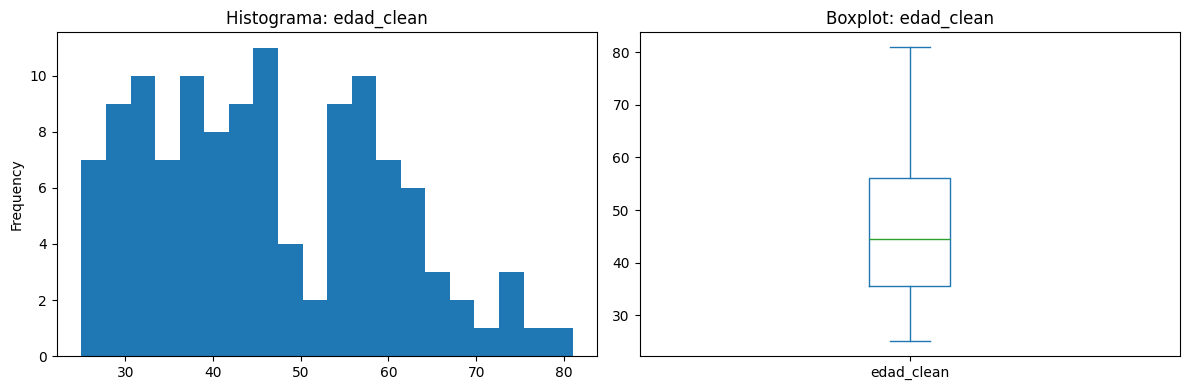


Peso - valores imposibles: 0


count    120.00000
mean      70.29250
std       10.99952
min       53.00000
25%       62.00000
50%       68.00000
75%       77.25000
max      104.00000
Name: peso_clean, dtype: float64

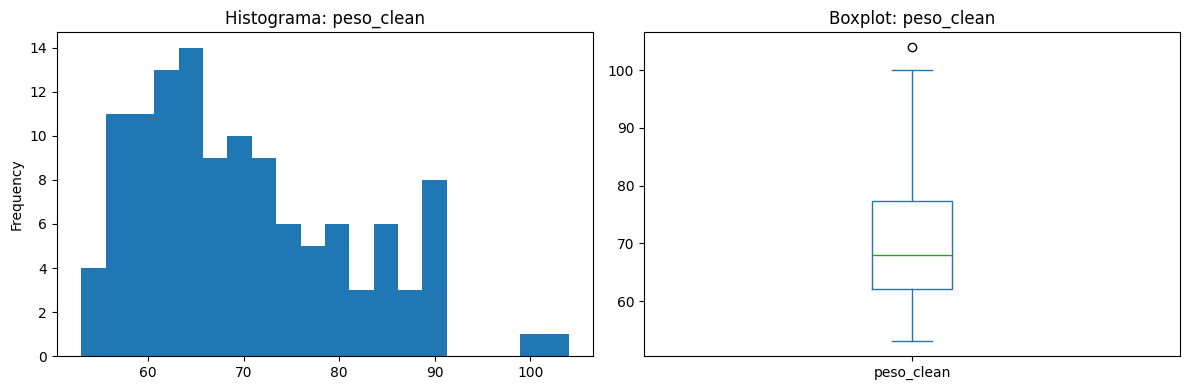


Talla - valores imposibles: 0


count    120.000000
mean     170.241667
std        1.851621
min      167.000000
25%      169.000000
50%      170.000000
75%      172.000000
max      173.000000
Name: talla_clean, dtype: float64

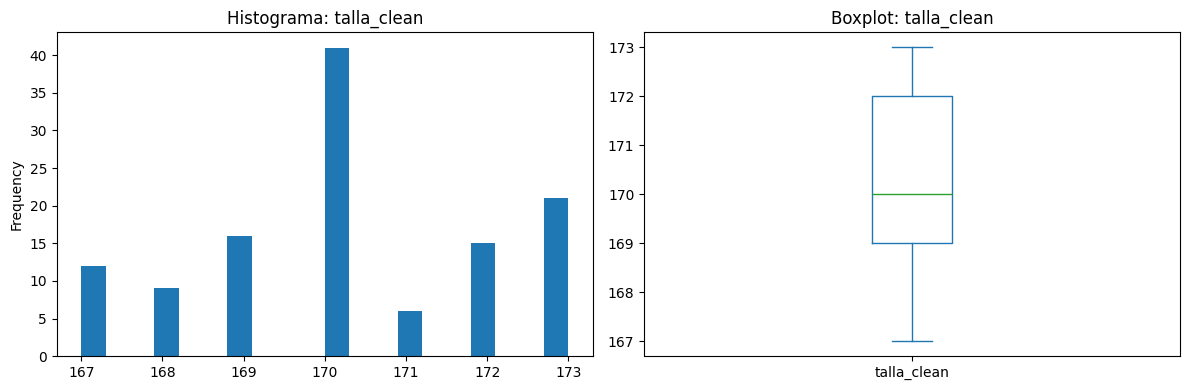


Domicilio antes:
domicilio_antes_clean
Piso en bloque de menos 50 viviendas     80
Casa unifamiliar                         19
Piso en bloque de más de 50 viviendas    19
Casa con espacio al aire libre            2
Name: count, dtype: int64

Afluencia antes:
afluencia_antes_clean
Medio    63
Alto     41
Bajo     16
Name: count, dtype: int64

Convivientes antes: {0: 120}

Profesión antes:
profesion_antes_clean
Ámbito educativo                                                            28
Ámbito administrativo                                                       17
Ámbito sanitario o de cuidados a terceros                                   12
Ámbito de la Investigación y el Desarrollo                                  11
Sin ocupación previa                                                         9
Ámbito de la construcción y mantenimiento                                    5
Jubilado                                                                     5
Ámbito comercial                 

In [17]:
# ============ BLOQUE P1: LIMPIEZA COLUMNA A COLUMNA ============

# --- 1. Código postal (1.CPBARRIO-ANTES_1) ---
# Tipo: numérico/texto. Problema: puede perder ceros a la izquierda al ser int.
df_trabajo["cp_antes_clean"] = df_trabajo["1.CPBARRIO-ANTES_1"].astype(str).str.zfill(5)
# Verificamos que todos tienen 5 dígitos
print("CP antes - valores únicos:", df_trabajo["cp_antes_clean"].nunique())
resumen_columna(df_trabajo, "cp_antes_clean")

# --- 1.1 Barrio (1.CPBARRIO-ANTES_2) ---
# Tipo: texto nominal. Problema: mayúsculas, tildes, variantes.
df_trabajo["barrio_antes_clean"] = (df_trabajo["1.CPBARRIO-ANTES_2"]
    .str.strip().str.title()
    .replace({"Malaga": "Málaga", "Centro Historico": "Centro Histórico",
              "Centro Histórico": "Centro", "Teatino": "Teatinos"}))
ver_categorica(df_trabajo, "barrio_antes_clean")

# --- 2. Sexo (2.SEXO_1) ---
# Tipo: categórica nominal binaria. Problema: formato "Hombre:" con dos puntos.
df_trabajo["sexo_clean"] = (df_trabajo["2.SEXO_1"]
    .str.replace(":", "", regex=False).str.strip().str.capitalize())
# Unificar variantes
df_trabajo["sexo_clean"] = df_trabajo["sexo_clean"].replace({
    "H": "Hombre", "M": "Mujer", "Masculino": "Hombre", "Femenino": "Mujer"})
print("\nSexo limpio:")
print(df_trabajo["sexo_clean"].value_counts(dropna=False))

# --- 3. Edad (3.EDAD_1) ---
# Tipo: numérica. Problema: posibles valores imposibles/outliers.
df_trabajo["edad_clean"] = pd.to_numeric(df_trabajo["3.EDAD_1"], errors="coerce")
# Valores imposibles: < 0 o > 120
mask_edad = (df_trabajo["edad_clean"] < 0) | (df_trabajo["edad_clean"] > 120)
print(f"\nEdad - valores imposibles: {mask_edad.sum()}")
df_trabajo.loc[mask_edad, "edad_clean"] = np.nan
ver_numerica(df_trabajo, "edad_clean")

# --- 4. Peso (4.PESO_1) ---
# Tipo: numérica. Problema: valores extremos, posibles errores de unidad.
df_trabajo["peso_clean"] = pd.to_numeric(df_trabajo["4.PESO_1"], errors="coerce")
# Valores imposibles: < 30 o > 250
mask_peso = (df_trabajo["peso_clean"] < 30) | (df_trabajo["peso_clean"] > 250)
print(f"\nPeso - valores imposibles: {mask_peso.sum()}")
df_trabajo.loc[mask_peso, "peso_clean"] = np.nan
ver_numerica(df_trabajo, "peso_clean")

# --- 5. Talla (5TALLA_1) ---
# Tipo: numérica. Problema: mezcla cm/m.
df_trabajo["talla_clean"] = pd.to_numeric(df_trabajo["5TALLA_1"], errors="coerce")
# Si está en metros (< 3), convertir a cm
df_trabajo.loc[df_trabajo["talla_clean"] < 3, "talla_clean"] *= 100
# Valores imposibles: < 100 o > 230
mask_talla = (df_trabajo["talla_clean"] < 100) | (df_trabajo["talla_clean"] > 230)
print(f"\nTalla - valores imposibles: {mask_talla.sum()}")
df_trabajo.loc[mask_talla, "talla_clean"] = np.nan
ver_numerica(df_trabajo, "talla_clean")

# --- 6. Domicilio antes (6.DOMICILIO-ANTES_1) ---
# Tipo: categórica nominal. Sin problemas graves, solo verificar categorías.
df_trabajo["domicilio_antes_clean"] = df_trabajo["6.DOMICILIO-ANTES_1"].str.strip()
print("\nDomicilio antes:")
print(df_trabajo["domicilio_antes_clean"].value_counts(dropna=False))

# --- 7. Afluencia antes (7.AFLUENCIA-ANTES_1) ---
# Tipo: categórica ordinal. Recodificamos a Bajo/Medio/Alto con orden numérico.
afluencia_map = {}
for v in df_trabajo["7.AFLUENCIA-ANTES_1"].dropna().unique():
    v_low = v.lower()
    if "bajo" in v_low: afluencia_map[v] = "Bajo"
    elif "medio" in v_low: afluencia_map[v] = "Medio"
    elif "alto" in v_low: afluencia_map[v] = "Alto"
df_trabajo["afluencia_antes_clean"] = df_trabajo["7.AFLUENCIA-ANTES_1"].map(afluencia_map)
df_trabajo["afluencia_antes_ord"] = df_trabajo["afluencia_antes_clean"].map({"Bajo": 0, "Medio": 1, "Alto": 2})
print("\nAfluencia antes:")
print(df_trabajo["afluencia_antes_clean"].value_counts(dropna=False))

# --- 8. Convivencia antes (8.CONVIVENCIA-ANTES_1) ---
# Tipo: numérica discreta. En este subconjunto todos son 0.
df_trabajo["convivientes_antes_clean"] = pd.to_numeric(df_trabajo["8.CONVIVENCIA-ANTES_1"], errors="coerce")
print("\nConvivientes antes:", df_trabajo["convivientes_antes_clean"].value_counts(dropna=False).to_dict())
# Nota: todos valen 0 en este subconjunto, lo cual es sospechoso.
# Puede ser un error de codificación. Lo marcamos en la auditoría.

# --- 9. Edades convivientes (9.ED,DES-,NTES_1) ---
# Tipo: texto libre/lista. Muy corrupta. Muchos NaN y valores como "," o "N,".
# Estrategia: extraer número de edades mencionadas si es posible.
def contar_edades(val):
    if pd.isna(val): return np.nan
    s = str(val)
    if s in ["0", "0.0", "0.1"]: return 0
    nums = re.findall(r"\d+", s)
    return len(nums) if nums else np.nan

df_trabajo["n_edades_conv_antes"] = df_trabajo["9.ED,DES-,NTES_1"].apply(contar_edades)

# --- 10. Profesión antes (10.PROFESION-ANTES_1) ---
# Tipo: categórica nominal. Categorías ya bastante limpias.
df_trabajo["profesion_antes_clean"] = df_trabajo["10.PROFESION-ANTES_1"].str.strip()
print("\nProfesión antes:")
print(df_trabajo["profesion_antes_clean"].value_counts(dropna=False).head(10))

# --- 11. Lugar de trabajo (11.LUGARTRABAJO-ANTES_1) ---
# Tipo: categórica nominal. Algunas respuestas libres fuera de las categorías principales.
principales_lt = df_trabajo["11.LUGARTRABAJO-ANTES_1"].value_counts()
categorias_principales = principales_lt[principales_lt >= 5].index.tolist()
df_trabajo["lugar_trabajo_antes_clean"] = df_trabajo["11.LUGARTRABAJO-ANTES_1"].apply(
    lambda x: x if x in categorias_principales else ("Otro" if pd.notna(x) else np.nan))
print("\nLugar trabajo antes (limpio):")
print(df_trabajo["lugar_trabajo_antes_clean"].value_counts(dropna=False))

# --- 12. Ocio (12.OCIO_1) ---
# Tipo: categórica nominal. Alguna respuesta libre rara.
principales_ocio = df_trabajo["12.OCIO_1"].value_counts()
cats_ocio = principales_ocio[principales_ocio >= 5].index.tolist()
df_trabajo["ocio_clean"] = df_trabajo["12.OCIO_1"].apply(
    lambda x: x if x in cats_ocio else ("Otro" if pd.notna(x) else np.nan))

# --- 13. Transporte (13.TRANSPORTE_1 a _7) ---
# Tipo: tabla ordinal multicolumna (frecuencia de uso por tipo de transporte).
# Valores: Nula/Muy baja/Baja/Media/Frecuente. Algunos tienen valores combinados.
transport_ord = {"Nula": 0, "Muy baja": 1, "Baja": 2, "Media": 3, "Frecuente": 4}
for i in range(1, 8):
    col = f"13.TRANSPORTE_{i}"
    if col in df_trabajo.columns:
        # Tomar el primer valor si hay combinados (ej: "Muy baja, Baja")
        df_trabajo[f"transporte_{i}_clean"] = (df_trabajo[col]
            .str.split(",").str[0].str.strip().map(transport_ord))

# Variable resumen: máximo uso de transporte público
transport_cols_clean = [f"transporte_{i}_clean" for i in range(1, 8) if f"transporte_{i}_clean" in df_trabajo.columns]
df_trabajo["max_transporte"] = df_trabajo[transport_cols_clean].max(axis=1)

# --- 14. Viaje al extranjero (14.EXTRANJERO_1) ---
# Tipo: mixta sí/no + texto destino. Problema: inconsistencia No/NO/no, Si con destino.
df_trabajo["viaje_extranjero_bin"] = df_trabajo["14.EXTRANJERO_1"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower().startswith("no")
    else (1 if pd.notna(x) else np.nan))
# Extraer destino
def extraer_destino(val):
    if pd.isna(val): return np.nan
    s = str(val).strip()
    if s.lower().startswith("no"): return np.nan
    # Quitar "Si", "Sí", "SI" del inicio
    dest = re.sub(r"^s[ií][!.,/\s]*\s*", "", s, flags=re.IGNORECASE).strip()
    return dest if dest else np.nan
df_trabajo["destino_extranjero"] = df_trabajo["14.EXTRANJERO_1"].apply(extraer_destino)
print("\nViaje extranjero:")
print(df_trabajo["viaje_extranjero_bin"].value_counts(dropna=False))

# --- 15. Desplazamiento nacional (15.DESPLAZAMIENTO-NACIONAL_1) ---
# Tipo: categórica nominal. Crear indicador binario de desplazamiento.
df_trabajo["desplazamiento_nac_bin"] = df_trabajo["15.DESPLAZAMIENTO-NACIONAL_1"].apply(
    lambda x: 0 if pd.notna(x) and "no he salido" in str(x).lower()
    else (1 if pd.notna(x) else np.nan))

# Actualizar auditoría para P1
idx_p1 = auditoria["columna_original"].isin(cols_p1)
auditoria.loc[idx_p1, "problemas_detectados"] = "Ver análisis P1 detallado arriba"
auditoria.loc[idx_p1, "estrategia_aplicada"] = "Normalización, recodificación, extracción de indicadores"
auditoria.loc[idx_p1, "columnas_generadas"] = "cp_antes_clean, barrio_antes_clean, sexo_clean, edad_clean, peso_clean, talla_clean, domicilio_antes_clean, afluencia_antes_clean/ord, convivientes_antes_clean, n_edades_conv_antes, profesion_antes_clean, lugar_trabajo_antes_clean, ocio_clean, transporte_*_clean, max_transporte, viaje_extranjero_bin, destino_extranjero, desplazamiento_nac_bin"
print("\n✓ Bloque P1 completado")



## Bloque P2 — Hábitos de convivencia y sociales **DURANTE** el confinamiento

Preguntas:

- **16 y 16.1**: código postal y barrio durante el confinamiento.
- **17 y 18**: tipo de domicilio y afluencia.
- **19 y 20**: número y edades de convivientes.
- **21**: mascotas.
- **22**: ámbito y forma de ejercer la profesión.
- **23**: lugar de trabajo.
- **24**: mes de inicio de medidas de seguridad.
- **25**: frecuencia de medidas de seguridad.

### Sugerencias específicas

- Compara P1 frente a P2 cuando tenga sentido: domicilio, afluencia, convivencia, etc.
- En **21** y **22** puede haber problemas de coherencia entre varias marcas.
- En **24** y **25** hay estructura **ordinal**: decide si conviene conservar texto, codificar ordinalmente o ambas cosas.

In [18]:
preguntas_p2 = ["16", "16.1", "17", "18", "19", "20", "21", "22", "23", "24", "25"]
cols_p2 = columnas_por_bloque(df_trabajo, preguntas_p2)

display(auditoria[auditoria["columna_original"].isin(cols_p2)])

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
22,16.CPBARRIO-DURANTE_1,16,float64,4,3.333333,89,P2,Código postal durante el confinamiento,texto/código,igual que P1.1,,,
23,16.CPBARRIO-DURANTE_2,16,str,8,6.666667,98,P2,Código postal durante el confinamiento,texto/código,igual que P1.1,,,
24,17.DOMICILIO-DURANTE_1,17,str,3,2.500000,4,P2,Tipo de domicilio durante,categórica nominal,comparar con P1.6,,,
25,18.AFLUENCIA-DURANTE_1,18,str,3,2.500000,3,P2,Afluencia en la zona durante,categórica ordinal,comparar con P1.7,,,
26,19.CONVIVENCIA-DURANTE_1,19,str,3,2.500000,8,P2,Número de convivientes durante,numérica discreta,"enteros, extremos, comparación con P1.8",,,
27,20.EDADES-DURANTE_1,20,object,57,47.500000,29,P2,Edades de convivientes durante,texto/lista,"parseo, resúmenes, consistencia con P2.19",,,
28,21.MASCOTAS_1,21,str,3,2.500000,6,P2,Convivencia con mascotas,multirrespuesta / nominal,no/perro/gato/otras; consistencia entre marcas,,,
29,21.MASCOTAS_2,21,str,120,100.000000,0,P2,Convivencia con mascotas,multirrespuesta / nominal,no/perro/gato/otras; consistencia entre marcas,,,
30,21.MASCOTAS_3,21,str,120,100.000000,0,P2,Convivencia con mascotas,multirrespuesta / nominal,no/perro/gato/otras; consistencia entre marcas,,,
31,21.MASCOTAS_4,21,str,120,100.000000,0,P2,Convivencia con mascotas,multirrespuesta / nominal,no/perro/gato/otras; consistencia entre marcas,,,


In [19]:
# ============ BLOQUE P2: DURANTE EL CONFINAMIENTO ============

# --- 16. CP durante (16.CPBARRIO-DURANTE_1) ---
df_trabajo["cp_durante_clean"] = df_trabajo["16.CPBARRIO-DURANTE_1"].astype(str).str.replace(".0","",regex=False).str.zfill(5)
df_trabajo.loc[df_trabajo["cp_durante_clean"].str.contains("nan",case=False,na=False), "cp_durante_clean"] = np.nan

# --- 16.1. Barrio durante (16.CPBARRIO-DURANTE_2) ---
df_trabajo["barrio_durante_clean"] = df_trabajo["16.CPBARRIO-DURANTE_2"].str.strip().str.title()

# --- 17. Domicilio durante (17.DOMICILIO-DURANTE_1) ---
df_trabajo["domicilio_durante_clean"] = df_trabajo["17.DOMICILIO-DURANTE_1"].str.strip()

# --- 18. Afluencia durante (18.AFLUENCIA-DURANTE_1) ---
afluencia_map2 = {}
for v in df_trabajo["18.AFLUENCIA-DURANTE_1"].dropna().unique():
    v_low = v.lower()
    if "bajo" in v_low: afluencia_map2[v] = "Bajo"
    elif "medio" in v_low: afluencia_map2[v] = "Medio"
    elif "alto" in v_low: afluencia_map2[v] = "Alto"
df_trabajo["afluencia_durante_clean"] = df_trabajo["18.AFLUENCIA-DURANTE_1"].map(afluencia_map2)
df_trabajo["afluencia_durante_ord"] = df_trabajo["afluencia_durante_clean"].map({"Bajo": 0, "Medio": 1, "Alto": 2})

# --- 19. Convivientes durante (19.CONVIVENCIA-DURANTE_1) ---
# Problema: valores como "O", "Ninguna", "ninguna", "08"
conv_map = {"O": 0, "Ninguna": 0, "ninguna": 0, "08": 8}
df_trabajo["convivientes_durante_clean"] = df_trabajo["19.CONVIVENCIA-DURANTE_1"].replace(conv_map)
df_trabajo["convivientes_durante_clean"] = pd.to_numeric(df_trabajo["convivientes_durante_clean"], errors="coerce")
# Valores negativos o > 20 son imposibles
mask_conv = (df_trabajo["convivientes_durante_clean"] < 0) | (df_trabajo["convivientes_durante_clean"] > 20)
df_trabajo.loc[mask_conv, "convivientes_durante_clean"] = np.nan
print("Convivientes durante:")
print(df_trabajo["convivientes_durante_clean"].value_counts(dropna=False).head(10))

# --- 20. Edades durante (20.EDADES-DURANTE_1) ---
df_trabajo["n_edades_conv_durante"] = df_trabajo["20.EDADES-DURANTE_1"].apply(
    lambda x: len(re.findall(r"\d+", str(x))) if pd.notna(x) and str(x) not in ["0","0.0"] else (0 if str(x) in ["0","0.0"] else np.nan))

# --- 21. Mascotas (21.MASCOTAS_1 a _5) ---
# Columna principal tiene las respuestas. Columnas 2-5 están vacías en este subconjunto.
df_trabajo["tiene_mascota"] = df_trabajo["21.MASCOTAS_1"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower() == "no" else (1 if pd.notna(x) else np.nan))
df_trabajo["tiene_perro"] = df_trabajo["21.MASCOTAS_1"].str.contains("Perro", case=False, na=False).astype(int)
df_trabajo["tiene_gato"] = df_trabajo["21.MASCOTAS_1"].str.contains("Gato", case=False, na=False).astype(int)
# Número de tipos de mascota
df_trabajo["n_tipos_mascota"] = df_trabajo["tiene_perro"] + df_trabajo["tiene_gato"] + df_trabajo["21.MASCOTAS_1"].str.contains("Otra", case=False, na=False).astype(int)

# --- 22. Profesión durante (22.PROFESION-DURANTE_1 a _12) ---
# Multicolumna. Contar cuántas formas de ejercer profesión se marcaron.
prof_durante_cols = [c for c in df_trabajo.columns if c.startswith("22.PROFESION-DURANTE")]
df_trabajo["n_formas_profesion"] = df_trabajo[prof_durante_cols].notna().sum(axis=1)

# --- 23. Lugar trabajo durante (23.LUGARTRABAJO-DURANTE_1) ---
df_trabajo["lugar_trabajo_durante_clean"] = df_trabajo["23.LUGARTRABAJO-DURANTE_1"].str.strip()
principales_ltd = df_trabajo["lugar_trabajo_durante_clean"].value_counts()
cats_ltd = principales_ltd[principales_ltd >= 3].index.tolist()
df_trabajo["lugar_trabajo_durante_clean"] = df_trabajo["lugar_trabajo_durante_clean"].apply(
    lambda x: x if x in cats_ltd else ("Otro" if pd.notna(x) else np.nan))

# --- 24. Mes inicio seguridad (24.SEGURIDAD-MES_1 a _4) ---
# Ordinal: enero < febrero < marzo < abril
mes_ord = {"Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4}
mes_cols = [c for c in df_trabajo.columns if c.startswith("24.SEGURIDAD-MES")]
df_trabajo["mes_seguridad_ord"] = df_trabajo["24.SEGURIDAD-MES_1"].map(mes_ord)

# --- 25. Frecuencia medidas seguridad (25.SEGURIDAD-FRECUENCIA_1 a _5) ---
# Ordinal multicolumna. Codificar cada una.
freq_ord = {"Nunca": 0, "A veces": 1, "Frecuentemente": 2, "Siempre": 3}
for i in range(1, 6):
    col = f"25.SEGURIDAD-FRECUENCIA_{i}"
    if col in df_trabajo.columns:
        df_trabajo[f"seguridad_freq_{i}"] = df_trabajo[col].map(freq_ord)

# Promedio de frecuencia de medidas de seguridad
seg_cols = [f"seguridad_freq_{i}" for i in range(1, 6) if f"seguridad_freq_{i}" in df_trabajo.columns]
df_trabajo["media_seguridad"] = df_trabajo[seg_cols].mean(axis=1)

# Actualizar auditoría P2
idx_p2 = auditoria["columna_original"].isin(cols_p2)
auditoria.loc[idx_p2, "problemas_detectados"] = "Texto en numéricos, NaN, multi-respuesta"
auditoria.loc[idx_p2, "estrategia_aplicada"] = "Conversión, mapeo ordinal, agregación"
auditoria.loc[idx_p2, "columnas_generadas"] = "cp/barrio/domicilio/afluencia durante, convivientes_durante_clean, tiene_mascota, n_tipos_mascota, n_formas_profesion, mes_seguridad_ord, media_seguridad"
print("\n✓ Bloque P2 completado")



Convivientes durante:
convivientes_durante_clean
0.0    89
1.0    15
2.0    10
NaN     3
3.0     2
8.0     1
Name: count, dtype: int64

✓ Bloque P2 completado


## Bloque P3 — Estado de salud y hábitos personales

Preguntas:

- **26**: tabaquismo.
- **27**: alcohol.
- **28**: bebidas estimulantes.
- **29, 30, 31**: medicación/tratamientos.
- **32**: consumo de productos.
- **33**: estado de salud general.
- **34, 35, 36, 37, 38, 39**: grupos de enfermedades.
- **40 y 40.1**: EPOC y condiciones de riesgo.

### Sugerencias específicas

- En **26** hay mezcla de categorías que parecen tener orden y otras que no.
- En **28** y **32** hay tablas de frecuencia: trata la ordinalidad con cuidado.
- En **34–39** hay muchas columnas binarias/ternarias: revisa **consistencia** y unifica codificación.
- En **40.1** puede haber multirrespuesta y posible contradicción entre `No` y otra condición marcada.

In [20]:
preguntas_p3 = ["26", "27", "28", "29", "30", "31", "32", "33", "34", "35", "36", "37", "38", "39", "40", "40.1"]
cols_p3 = columnas_por_bloque(df_trabajo, preguntas_p3)

display(auditoria[auditoria["columna_original"].isin(cols_p3)])

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
55,26.FUMADOR_1,26,str,0,0.000000,7,P3,Tabaquismo,categórica mixta,"orden parcial, fumador social/pasivo/vapeo/otro",,,
56,27.ALCOHOL_1,27,str,1,0.833333,3,P3,Consumo de alcohol,categórica nominal/ordinal,no/puntual/habitual/otro,,,
57,28.BEBIDAS_1,28,str,6,5.000000,3,P3,Bebidas estimulantes,tabla ordinal multicolumna,nunca/ocasional/frecuente,,,
58,28.BEBIDAS_2,28,str,11,9.166667,3,P3,Bebidas estimulantes,tabla ordinal multicolumna,nunca/ocasional/frecuente,,,
59,28.BEBIDAS_3,28,str,10,8.333333,3,P3,Bebidas estimulantes,tabla ordinal multicolumna,nunca/ocasional/frecuente,,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...
111,39.ENF-OTRAS_5,39,str,7,5.833333,3,P3,Patologías en los últimos 2 años,multicolumna ternaria,sí/no/no sé por patología,,,
112,39.ENF-OTRAS_6,39,str,120,100.000000,0,P3,Patologías en los últimos 2 años,multicolumna ternaria,sí/no/no sé por patología,,,
113,39.ENF-OTRAS_7,39,str,120,100.000000,0,P3,Patologías en los últimos 2 años,multicolumna ternaria,sí/no/no sé por patología,,,
114,40.EPOC-RIESGO_1,40,str,5,4.166667,2,P3,EPOC,categórica binaria,"sí/no, faltantes",,,


In [21]:
# ============ BLOQUE P3: SALUD Y HÁBITOS ============

# --- 26. Fumador (26.FUMADOR_1) ---
fumador_map = {}
for v in df_trabajo["26.FUMADOR_1"].dropna().unique():
    vl = v.lower()
    if "no" in vl and "fumador" in vl: fumador_map[v] = "No fumador"
    elif "ex" in vl: fumador_map[v] = "Ex fumador"
    elif "social" in vl or "ocasional" in vl: fumador_map[v] = "Fumador ocasional"
    elif "diario" in vl or "habitual" in vl: fumador_map[v] = "Fumador habitual"
    elif "pasivo" in vl: fumador_map[v] = "Fumador pasivo"
    elif "vapeo" in vl or "electr" in vl: fumador_map[v] = "Vapeo"
    else: fumador_map[v] = v
df_trabajo["fumador_clean"] = df_trabajo["26.FUMADOR_1"].map(fumador_map)
df_trabajo["fumador_bin"] = df_trabajo["fumador_clean"].apply(
    lambda x: 1 if pd.notna(x) and x not in ["No fumador","Ex fumador"] else (0 if pd.notna(x) else np.nan))
print("Fumador:")
print(df_trabajo["fumador_clean"].value_counts(dropna=False))

# --- 27. Alcohol (27.ALCOHOL_1) ---
alcohol_map = {"No": 0, "Puntualmente": 1, "Habitualmente": 2}
df_trabajo["alcohol_ord"] = df_trabajo["27.ALCOHOL_1"].map(alcohol_map)
# Valores que no encajan se asignan como NaN (ya quedan así por map)

# --- 28. Bebidas estimulantes (28.BEBIDAS_1 a _6) ---
bebida_ord = {"Nunca": 0, "Ocasionalmente": 1, "Frecuentemente": 2, "Diariamente": 3}
for i in range(1, 7):
    col = f"28.BEBIDAS_{i}"
    if col in df_trabajo.columns:
        df_trabajo[f"bebida_{i}_ord"] = df_trabajo[col].map(bebida_ord)
beb_cols = [f"bebida_{i}_ord" for i in range(1,7) if f"bebida_{i}_ord" in df_trabajo.columns]
df_trabajo["media_bebidas"] = df_trabajo[beb_cols].mean(axis=1)

# --- 29, 30, 31. Medicación ---
for col_orig, col_new in [("29.ANTIDEPRESIVOS_1","antidepresivos_bin"),
                           ("30.TRANQUILIZANTES_1","tranquilizantes_bin"),
                           ("31.TRATAMIENTO-DOLOR_1","trat_dolor_bin")]:
    df_trabajo[col_new] = df_trabajo[col_orig].apply(
        lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s")
        else (0 if pd.notna(x) and str(x).strip().lower().startswith("n") else np.nan))

# --- 32. Suplementos (32.SUPLEMENTOS_1 a _3) ---
sup_ord = {"Nunca": 0, "De vez en cuando": 1, "Habitualmente": 2}
for i in range(1, 4):
    col = f"32.SUPLEMENTOS_{i}"
    if col in df_trabajo.columns:
        df_trabajo[f"suplemento_{i}_ord"] = df_trabajo[col].map(sup_ord)

# --- 33. Estado de salud (33.ESTADO-SALUD_1) ---
salud_ord = {"Excelente": 4, "Bueno": 3, "Regular": 2, "Malo": 1, "Muy malo": 0}
df_trabajo["salud_general_ord"] = df_trabajo["33.ESTADO-SALUD_1"].map(salud_ord)

# --- 34-39. Enfermedades multicolumna ---
# Estrategia: para cada bloque, contar cuántas enfermedades tiene (Sí=1)
enf_bloques = {
    "n_enf_metabolica": "34.ENF-METABOLICA",
    "n_enf_autoinmune": "35.ENF-AUTOINMUNE",
    "n_enf_alergia": "36.ENF-ALERGIA",
    "n_enf_respiratoria": "37.ENF-RESPIRATORIA",
    "n_enf_cardiaca": "38.ENF-CARDIACA",
    "n_enf_otras": "39.ENF-OTRAS",
}
for var_name, prefix in enf_bloques.items():
    cols_enf = [c for c in df_trabajo.columns if c.startswith(prefix)]
    # Contar columnas con valor "Si" o "Sí"
    df_trabajo[var_name] = 0
    for c in cols_enf:
        df_trabajo[var_name] += df_trabajo[c].apply(
            lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s") else 0)

# Indicador global de comorbilidad
enf_count_cols = list(enf_bloques.keys())
df_trabajo["total_enfermedades"] = df_trabajo[enf_count_cols].sum(axis=1)
df_trabajo["tiene_comorbilidad"] = (df_trabajo["total_enfermedades"] > 0).astype(int)
print("\nTotal enfermedades (distribución):")
print(df_trabajo["total_enfermedades"].value_counts().sort_index())

# --- 40. EPOC/Riesgo ---
df_trabajo["epoc_bin"] = df_trabajo["40.EPOC-RIESGO_1"].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s")
    else (0 if pd.notna(x) else np.nan))
# 40.EPOC-RIESGO_2: condiciones de riesgo
df_trabajo["condicion_riesgo_bin"] = df_trabajo["40.EPOC-RIESGO_2"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower() == "no"
    else (1 if pd.notna(x) else np.nan))

idx_p3 = auditoria["columna_original"].isin(cols_p3)
auditoria.loc[idx_p3, "problemas_detectados"] = "Multi-respuesta, categorías mixtas, codificación inconsistente"
auditoria.loc[idx_p3, "estrategia_aplicada"] = "Mapeo ordinal, conteo binario por bloque, indicador comorbilidad"
auditoria.loc[idx_p3, "columnas_generadas"] = "fumador_clean/bin, alcohol_ord, bebida_*_ord, antidepresivos/tranquilizantes/trat_dolor_bin, salud_general_ord, n_enf_*, total_enfermedades, tiene_comorbilidad, epoc_bin"
print("\n✓ Bloque P3 completado")


Fumador:
fumador_clean
No                                       88
Fumador habitual                         23
Fumador ocasional                         7
dejé de fumar en confinamiento            1
No tabaco. Marihuana sin combustión p     1
Name: count, dtype: int64

Total enfermedades (distribución):
total_enfermedades
0     20
1     24
2     19
3     15
4     16
5     11
6      4
7      4
8      2
9      4
11     1
Name: count, dtype: int64

✓ Bloque P3 completado


## Bloque P4 — Estado de salud durante el confinamiento

Preguntas:

- **41**: estado de salud en los últimos meses.
- **42, 43, 44, 45**: ingreso hospitalario, visitas al hospital y otras patologías.
- **46**: sintomatología.

### Sugerencias específicas

- En **41** hay una variable ordinal clara.
- En **42**, **44** y **45** puede haber mezcla entre sí/no y texto libre en “otro”.
- En **46** tendrás varias columnas binarias: revisa si todas usan la misma codificación y crea variables resumen si están justificadas.

In [22]:
preguntas_p4 = ["41", "42", "43", "44", "45", "46"]
cols_p4 = columnas_por_bloque(df_trabajo, preguntas_p4)

display(auditoria[auditoria["columna_original"].isin(cols_p4)])

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
116,41.SALUD-TRIMESTRE_1,41,str,0,0.000000,5,P4,Estado de salud últimos meses,categórica ordinal,excelente/bueno/regular/malo/otro,,,
117,42.HOSPITAL-INGRESO_1,42,str,1,0.833333,13,P4,Patología con ingreso hospitalario,categórica nominal,sí/no/otro + posible texto,,,
118,43.HOSPITAL-PRUEBAS_1,43,str,0,0.000000,2,P4,Visita a centro hospitalario,categórica binaria,sí/no,,,
119,44.PATOLOGIA-CONSIS_1,44,str,2,1.666667,31,P4,Otra patología con asistencia médica,categórica nominal,sí/no/otro,,,
120,45.PATOLOGIA-SINASIS_1,45,str,3,2.500000,24,P4,Otra patología sin asistencia médica,categórica nominal,sí/no/otro,,,
121,46.SINTOMATOLOGIA_1,46,str,7,5.833333,2,P4,Sintomatología reciente,multicolumna binaria,"sí/no por síntoma, consistencia",,,
122,46.SINTOMATOLOGIA_2,46,str,10,8.333333,2,P4,Sintomatología reciente,multicolumna binaria,"sí/no por síntoma, consistencia",,,
123,46.SINTOMATOLOGIA_3,46,str,9,7.500000,2,P4,Sintomatología reciente,multicolumna binaria,"sí/no por síntoma, consistencia",,,
124,46.SINTOMATOLOGIA_4,46,str,6,5.000000,2,P4,Sintomatología reciente,multicolumna binaria,"sí/no por síntoma, consistencia",,,
125,46.SINTOMATOLOGIA_5,46,str,9,7.500000,2,P4,Sintomatología reciente,multicolumna binaria,"sí/no por síntoma, consistencia",,,


In [23]:
# ============ BLOQUE P4: SALUD DURANTE CONFINAMIENTO ============

# --- 41. Salud trimestre (41.SALUD-TRIMESTRE_1) ---
df_trabajo["salud_trimestre_ord"] = df_trabajo["41.SALUD-TRIMESTRE_1"].map(salud_ord)
print("Salud trimestre:")
print(df_trabajo["salud_trimestre_ord"].value_counts(dropna=False))

# --- 42. Ingreso hospitalario (42.HOSPITAL-INGRESO_1) ---
df_trabajo["ingreso_hospital_bin"] = df_trabajo["42.HOSPITAL-INGRESO_1"].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s")
    else (0 if pd.notna(x) and str(x).strip().lower().startswith("n") else np.nan))

# --- 43. Visita hospital (43.HOSPITAL-PRUEBAS_1) ---
df_trabajo["visita_hospital_bin"] = df_trabajo["43.HOSPITAL-PRUEBAS_1"].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s")
    else (0 if pd.notna(x) and str(x).strip().lower().startswith("n") else np.nan))

# --- 44. Patología con asistencia (44.PATOLOGIA-CONSIS_1) ---
df_trabajo["patologia_asist_bin"] = df_trabajo["44.PATOLOGIA-CONSIS_1"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower() == "no"
    else (1 if pd.notna(x) else np.nan))

# --- 45. Patología sin asistencia (45.PATOLOGIA-SINASIS_1) ---
df_trabajo["patologia_sinasist_bin"] = df_trabajo["45.PATOLOGIA-SINASIS_1"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower() == "no"
    else (1 if pd.notna(x) else np.nan))

# --- 46. Sintomatología (46.SINTOMATOLOGIA_1 a _18) ---
# Columnas binarias Si/No por síntoma. Unificar y contar.
sint_cols = [c for c in df_trabajo.columns if c.startswith("46.SINTOMATOLOGIA")]
for c in sint_cols:
    col_clean = c.replace(".", "_").replace("-", "_") + "_bin"
    df_trabajo[col_clean] = df_trabajo[c].apply(
        lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("s")
        else (0 if pd.notna(x) and str(x).strip().lower().startswith("n") else np.nan))

sint_bin_cols = [c.replace(".", "_").replace("-", "_") + "_bin" for c in sint_cols]
sint_bin_exist = [c for c in sint_bin_cols if c in df_trabajo.columns]
df_trabajo["numero_sintomas"] = df_trabajo[sint_bin_exist].sum(axis=1)

# Agrupar por tipo de síntoma (basado en orden típico del cuestionario COVID):
# 1-3: respiratorios (tos, disnea, dolor garganta)
# 4-6: generales (fiebre, cansancio, dolor muscular)
# 7-9: digestivos (diarrea, náuseas, dolor abdominal)
# 10-12: neurológicos (cefalea, anosmia, ageusia)
resp_cols = [c for c in sint_bin_exist[:3] if c in df_trabajo.columns]
gen_cols = [c for c in sint_bin_exist[3:6] if c in df_trabajo.columns]
dig_cols = [c for c in sint_bin_exist[6:9] if c in df_trabajo.columns]
neuro_cols = [c for c in sint_bin_exist[9:12] if c in df_trabajo.columns]

df_trabajo["sintoma_respiratorio"] = df_trabajo[resp_cols].max(axis=1) if resp_cols else 0
df_trabajo["sintoma_general"] = df_trabajo[gen_cols].max(axis=1) if gen_cols else 0
df_trabajo["sintoma_digestivo"] = df_trabajo[dig_cols].max(axis=1) if dig_cols else 0
df_trabajo["sintoma_neurologico"] = df_trabajo[neuro_cols].max(axis=1) if neuro_cols else 0

print("Número de síntomas (distribución):")
print(df_trabajo["numero_sintomas"].describe())

idx_p4 = auditoria["columna_original"].isin(cols_p4)
auditoria.loc[idx_p4, "problemas_detectados"] = "Binarios Si/No, texto libre en 44-45, multi-columna en 46"
auditoria.loc[idx_p4, "estrategia_aplicada"] = "Binarización, conteo síntomas, agrupación por tipo"
auditoria.loc[idx_p4, "columnas_generadas"] = "salud_trimestre_ord, ingreso/visita_hospital_bin, patologia_*_bin, numero_sintomas, sintoma_respiratorio/general/digestivo/neurologico"
print("\n✓ Bloque P4 completado")


Salud trimestre:
salud_trimestre_ord
3.0    79
4.0    21
2.0    18
1.0     1
NaN     1
Name: count, dtype: int64
Número de síntomas (distribución):
count    120.000000
mean       3.208333
std        2.795242
min        0.000000
25%        1.000000
50%        3.000000
75%        5.000000
max       15.000000
Name: numero_sintomas, dtype: float64

✓ Bloque P4 completado


## Bloque P5 — Información referente a vacunas y COVID

Preguntas:

- **47**: vacunas/enfermedades previas.
- **48**: convivencia con positivo COVID.
- **49**: sospecha de COVID.
- **50**: prueba PCR.
- **51**: anticuerpos.

### Sugerencias específicas

- En **47** vuelve a aparecer estructura multicolumna/ternaria.
- En **50** y **51** conviene revisar si la variable debe quedarse como texto categórico o si puede descomponerse en indicadores más simples.
- Piensa qué variable podría servir como **objetivo** o como **variable de interés clínica**.

In [24]:
preguntas_p5 = ["47", "48", "49", "50", "51"]
cols_p5 = columnas_por_bloque(df_trabajo, preguntas_p5)

display(auditoria[auditoria["columna_original"].isin(cols_p5)])

,columna_original,pregunta,dtype_raw,n_missing,pct_missing,n_unicos,bloque,descripcion,tipo_sugerido,foco_limpieza,problemas_detectados,estrategia_aplicada,columnas_generadas
139,47.VACUNAS_1,47,str,19,15.833333,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
140,47.VACUNAS_2,47,str,34,28.333333,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
141,47.VACUNAS_3,47,str,43,35.833333,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
142,47.VACUNAS_4,47,str,44,36.666667,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
143,47.VACUNAS_5,47,str,47,39.166667,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
144,47.VACUNAS_6,47,str,47,39.166667,2,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
145,47.VACUNAS_7,47,str,44,36.666667,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
146,47.VACUNAS_8,47,str,38,31.666667,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
147,47.VACUNAS_9,47,str,39,32.500000,3,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,
148,47.VACUNAS_10,47,str,120,100.000000,0,P5,Vacunas y enfermedades previas,multicolumna ternaria,sí/no/no sé por vacuna/enfermedad,,,


In [25]:
# ============ BLOQUE P5: VACUNAS Y COVID ============

# --- 47. Vacunas (47.VACUNAS_1 a _10) ---
vac_cols = [c for c in df_trabajo.columns if c.startswith("47.VACUNAS")]
# Codificar: Si=1, No=0, No se/no me consta=np.nan
for c in vac_cols:
    col_clean = c.replace(".", "_") + "_bin"
    df_trabajo[col_clean] = df_trabajo[c].apply(
        lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("si")
        else (0 if pd.notna(x) and str(x).strip().lower().startswith("no") and "no se" not in str(x).lower() and "no me" not in str(x).lower()
        else np.nan))
vac_bin_cols = [c.replace(".", "_") + "_bin" for c in vac_cols if c.replace(".", "_") + "_bin" in df_trabajo.columns]
df_trabajo["n_vacunas"] = df_trabajo[vac_bin_cols].sum(axis=1)

# --- 48. Contacto COVID (48.COVID-CONTACTO_1) ---
df_trabajo["covid_contacto_bin"] = df_trabajo["48.COVID-CONTACTO_1"].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("si")
    else (0 if pd.notna(x) and str(x).strip().lower().startswith("no")
    else np.nan))

# --- 49. Sospecha COVID (49.COVID-SOSPECHA_1) ---
df_trabajo["covid_sospecha_bin"] = df_trabajo["49.COVID-SOSPECHA_1"].apply(
    lambda x: 1 if pd.notna(x) and str(x).strip().lower().startswith("si")
    else (0 if pd.notna(x) and str(x).strip().lower().startswith("no")
    else np.nan))

# --- 50. PCR (50.COVID-PCR_1) ---
df_trabajo["covid_pcr_realizada"] = df_trabajo["50.COVID-PCR_1"].apply(
    lambda x: 0 if pd.notna(x) and str(x).strip().lower() == "no"
    else (1 if pd.notna(x) else np.nan))
df_trabajo["covid_pcr_positiva"] = df_trabajo["50.COVID-PCR_1"].apply(
    lambda x: 1 if pd.notna(x) and "positivo" in str(x).lower()
    else (0 if pd.notna(x) else np.nan))

# --- 51. Anticuerpos (51.COVID-ANTICUERPOS_1) ---
df_trabajo["covid_anticuerpos"] = df_trabajo["51.COVID-ANTICUERPOS_1"].apply(
    lambda x: 1 if pd.notna(x) and "anticuerpos" in str(x).lower() and "sin" not in str(x).lower()
    else (0 if pd.notna(x) else np.nan))

idx_p5 = auditoria["columna_original"].isin(cols_p5)
auditoria.loc[idx_p5, "problemas_detectados"] = "Ternario Si/No/No sé, texto libre largo en 48-49"
auditoria.loc[idx_p5, "estrategia_aplicada"] = "Binarización, extracción de indicadores PCR/anticuerpos"
auditoria.loc[idx_p5, "columnas_generadas"] = "n_vacunas, covid_contacto/sospecha_bin, covid_pcr_realizada/positiva, covid_anticuerpos"
print("\n✓ Bloque P5 completado")



✓ Bloque P5 completado


/tmp/ipykernel_34968/2020362111.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo[col_clean] = df_trabajo[c].apply(
/tmp/ipykernel_34968/2020362111.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo[col_clean] = df_trabajo[c].apply(
/tmp/ipykernel_34968/2020362111.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmente

# 7. Tratamiento de valores faltantes

Tras la limpieza básica, debes estudiar **qué columnas tienen faltantes** y decidir, de forma justificada, qué hacer en cada caso.

## Debes incluir ejemplos de:

1. **Eliminación** de filas o columnas, si la justificas.
2. **Imputación simple**:
   - media o mediana para numéricas,
   - moda para categóricas.
3. **Al menos una imputación más elaborada** o una estrategia razonada basada en otras columnas, si el caso lo merece.

## No se acepta

- rellenar todo “a ojo”;
- usar siempre la misma estrategia para todas las columnas;
- imputar sin explicar por qué.

In [26]:
# Tabla de faltantes tras limpieza
cols_limpias = [c for c in df_trabajo.columns if c.endswith(("_clean","_bin","_ord")) or c.startswith(("n_","total_","tiene_","media_","max_","numero_","sintoma_","covid_","fumador_"))]
missing_post = pd.DataFrame({
    "columna": cols_limpias,
    "n_missing": [df_trabajo[c].isna().sum() for c in cols_limpias],
    "pct_missing": [round(100*df_trabajo[c].isna().mean(),1) for c in cols_limpias]
}).sort_values("pct_missing", ascending=False)
display(missing_post[missing_post["pct_missing"] > 0])
print(f"\nColumnas con >50% faltantes (candidatas a eliminación): {(missing_post['pct_missing']>50).sum()}")


,columna,n_missing,pct_missing
44,bebida_3_ord,120,100.0
45,bebida_4_ord,120,100.0
42,bebida_1_ord,120,100.0
43,bebida_2_ord,120,100.0
47,bebida_6_ord,120,100.0
...,...,...,...
2,sexo_clean,1,0.8
11,profesion_antes_clean,1,0.8
21,max_transporte,1,0.8
66,salud_trimestre_ord,1,0.8



Columnas con >50% faltantes (candidatas a eliminación): 16


In [27]:
# Imputaciones justificadas

# 1. Edad: imputación por mediana (distribución asimétrica, la mediana es más robusta)
mediana_edad = df_trabajo["edad_clean"].median()
print(f"Imputando edad con mediana = {mediana_edad}")
df_trabajo["edad_clean"] = df_trabajo["edad_clean"].fillna(mediana_edad)

# 2. Peso: imputación por mediana condicionada al sexo
# Justificación: peso difiere significativamente por sexo
for sexo in ["Hombre", "Mujer"]:
    mask = df_trabajo["sexo_clean"] == sexo
    med = df_trabajo.loc[mask, "peso_clean"].median()
    df_trabajo.loc[mask & df_trabajo["peso_clean"].isna(), "peso_clean"] = med
    print(f"Imputando peso {sexo} con mediana = {med}")

# 3. Talla: imputación por mediana condicionada al sexo
for sexo in ["Hombre", "Mujer"]:
    mask = df_trabajo["sexo_clean"] == sexo
    med = df_trabajo.loc[mask, "talla_clean"].median()
    df_trabajo.loc[mask & df_trabajo["talla_clean"].isna(), "talla_clean"] = med
    print(f"Imputando talla {sexo} con mediana = {med}")

# 4. Sexo: imputación por moda (solo 1 faltante)
moda_sexo = df_trabajo["sexo_clean"].mode()[0]
df_trabajo["sexo_clean"] = df_trabajo["sexo_clean"].fillna(moda_sexo)
print(f"Imputando sexo con moda = {moda_sexo}")

# 5. Variables binarias de salud: mantener NaN donde la ausencia es informativa
# (no se imputa: el NaN indica que el encuestado no respondió esa parte)
# Esto es una decisión consciente para no introducir sesgo.
print("\nVariables binarias: NaN mantenido como informativo (no se imputa).")

# 6. Salud general: imputar con moda
if df_trabajo["salud_general_ord"].isna().any():
    moda_salud = df_trabajo["salud_general_ord"].mode()[0]
    df_trabajo["salud_general_ord"] = df_trabajo["salud_general_ord"].fillna(moda_salud)
    print(f"Imputando salud general con moda = {moda_salud}")


Imputando edad con mediana = 44.5
Imputando peso Hombre con mediana = 74.0
Imputando peso Mujer con mediana = 63.0
Imputando talla Hombre con mediana = 170.0
Imputando talla Mujer con mediana = 170.0
Imputando sexo con moda = Mujer

Variables binarias: NaN mantenido como informativo (no se imputa).
Imputando salud general con moda = 3.0


# 8. Detección y tratamiento de outliers

Debes aplicar este análisis, al menos, a las variables numéricas que finalmente consideres relevantes.

## Variables candidatas típicas

- edad,
- peso,
- talla,
- número de convivientes,
- resúmenes numéricos que extraigas de otras preguntas,
- IMC.

## Lo que debes hacer

1. Convertir la columna a numérica si es necesario.
2. Visualizar con histogramas y boxplots.
3. Detectar candidatos a outlier con **IQR** o **z-score**.
4. Decidir si son:
   - error de captura,
   - caso extremo real,
   - falta de unidad consistente,
   - dato que debe conservarse.
5. Aplicar una acción justificada:
   - corregir,
   - imputar,
   - marcar,
   - transformar,
   - eliminar (solo si se justifica muy bien).

count    120.000000
mean      46.091667
std       13.371860
min       25.000000
25%       35.500000
50%       44.500000
75%       56.000000
max       81.000000
Name: edad_clean, dtype: float64

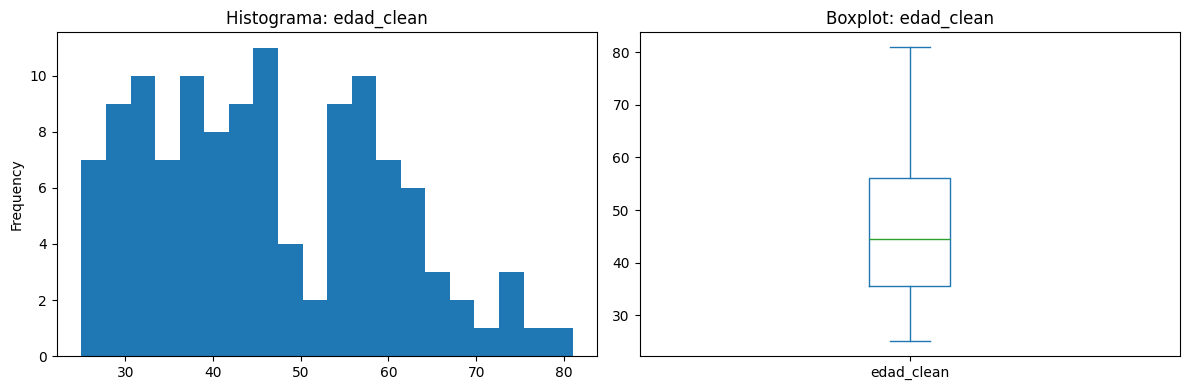


edad_clean: Q1=35.5, Q3=56.0, IQR=20.5
  Límites IQR: [4.8, 86.8]
  Outliers detectados: 0
  Outliers por z-score (>3): 0



count    120.00000
mean      70.29250
std       10.99952
min       53.00000
25%       62.00000
50%       68.00000
75%       77.25000
max      104.00000
Name: peso_clean, dtype: float64

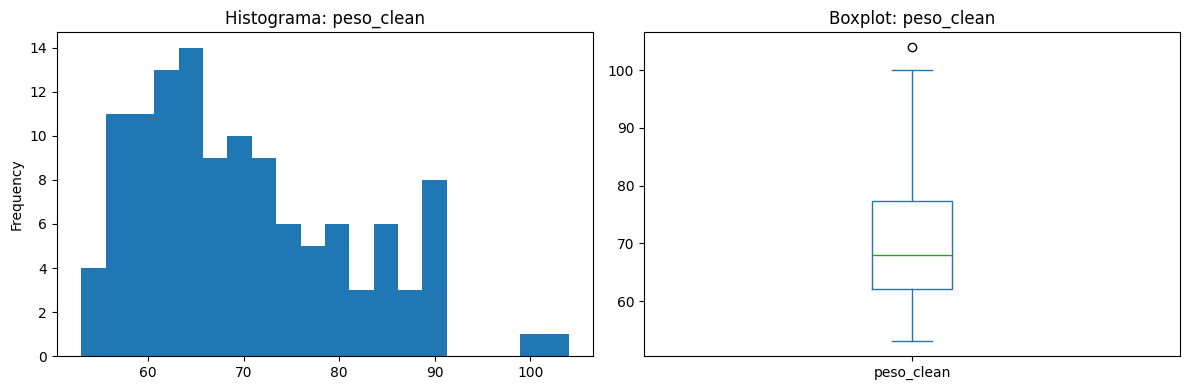


peso_clean: Q1=62.0, Q3=77.25, IQR=15.25
  Límites IQR: [39.1, 100.1]
  Outliers detectados: 1
  Valores: [104.0]
  Outliers por z-score (>3): 1



count    120.000000
mean     170.241667
std        1.851621
min      167.000000
25%      169.000000
50%      170.000000
75%      172.000000
max      173.000000
Name: talla_clean, dtype: float64

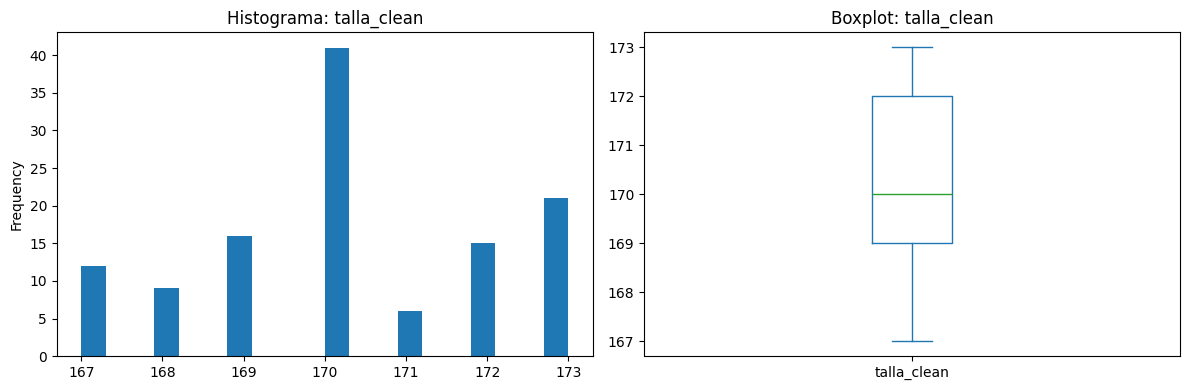


talla_clean: Q1=169.0, Q3=172.0, IQR=3.0
  Límites IQR: [164.5, 176.5]
  Outliers detectados: 0
  Outliers por z-score (>3): 0



In [28]:
# Detección de outliers en variables numéricas limpias
from scipy import stats

vars_num = ["edad_clean", "peso_clean", "talla_clean"]
for v in vars_num:
    ver_numerica(df_trabajo, v)
    
    s = df_trabajo[v].dropna()
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    outliers = s[(s < lower) | (s > upper)]
    print(f"\n{v}: Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"  Límites IQR: [{lower:.1f}, {upper:.1f}]")
    print(f"  Outliers detectados: {len(outliers)}")
    if len(outliers) > 0:
        print(f"  Valores: {outliers.tolist()}")
    
    # Z-score
    z = np.abs(stats.zscore(s))
    n_zscore = (z > 3).sum()
    print(f"  Outliers por z-score (>3): {n_zscore}")
    print()


In [29]:
# Tratamiento de outliers detectados
# Estrategia: los valores extremos que están fuera de 1.5*IQR se marcan como NaN
# si parecen errores de captura, o se conservan si son plausibles.

# Para peso: valores > upper se conservan si son < 200 (obesos reales)
s_peso = df_trabajo["peso_clean"].dropna()
Q1, Q3 = s_peso.quantile(0.25), s_peso.quantile(0.75)
IQR = Q3 - Q1
mask_peso_outlier = (df_trabajo["peso_clean"] < Q1 - 1.5*IQR) | (df_trabajo["peso_clean"] > 200)
n_corr = mask_peso_outlier.sum()
df_trabajo.loc[mask_peso_outlier, "peso_clean"] = np.nan
print(f"Peso: {n_corr} outliers extremos corregidos a NaN")

# Para talla: conservamos todos en rango [140, 210], fuera → NaN
mask_talla_outlier = (df_trabajo["talla_clean"] < 140) | (df_trabajo["talla_clean"] > 210)
n_corr_t = mask_talla_outlier.sum()
df_trabajo.loc[mask_talla_outlier, "talla_clean"] = np.nan
print(f"Talla: {n_corr_t} outliers extremos corregidos a NaN")

# Re-imputar si se crearon nuevos NaN
for sexo in ["Hombre", "Mujer"]:
    mask = df_trabajo["sexo_clean"] == sexo
    for col in ["peso_clean", "talla_clean"]:
        med = df_trabajo.loc[mask & df_trabajo[col].notna(), col].median()
        df_trabajo.loc[mask & df_trabajo[col].isna(), col] = med


Peso: 0 outliers extremos corregidos a NaN
Talla: 0 outliers extremos corregidos a NaN


# 9. Transformación de datos

En esta parte debes aplicar **transformaciones con sentido**.

## Obligatorio

### 9.1. Creación de nuevas variables
Debes crear varias variables derivadas. Algunas candidatas son:

- `imc` a partir de peso y talla;
- número de convivientes;
- número de mascotas;
- número de enfermedades por bloque;
- número de síntomas;
- indicadores binarios de riesgo.

### 9.2. Codificación de variables categóricas
Debes usar, cuando corresponda:

- **One-Hot Encoding** para variables nominales;
- **Ordinal Encoding** para variables con orden lógico;
- **Label Encoding** solo si justificas por qué no introduces una jerarquía artificial.

### 9.3. Escalado/normalización
Aplica y compara, al menos sobre algunas variables numéricas limpias:

- Min–Max,
- Z-score,
- o normalización decimal.

### 9.4. Discretización
Discretiza, al menos, una variable continua de forma justificada:
por ejemplo edad, IMC o número de convivientes.

IMC - estadísticas:
count    120.000000
mean      24.254167
std        3.748499
min       18.600000
25%       21.400000
50%       23.300000
75%       26.550000
max       35.200000
Name: imc, dtype: float64


/tmp/ipykernel_34968/3575543100.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["imc"] = df_trabajo["peso_clean"] / (df_trabajo["talla_clean"] / 100) ** 2


count    120.000000
mean      24.254167
std        3.748499
min       18.600000
25%       21.400000
50%       23.300000
75%       26.550000
max       35.200000
Name: imc, dtype: float64

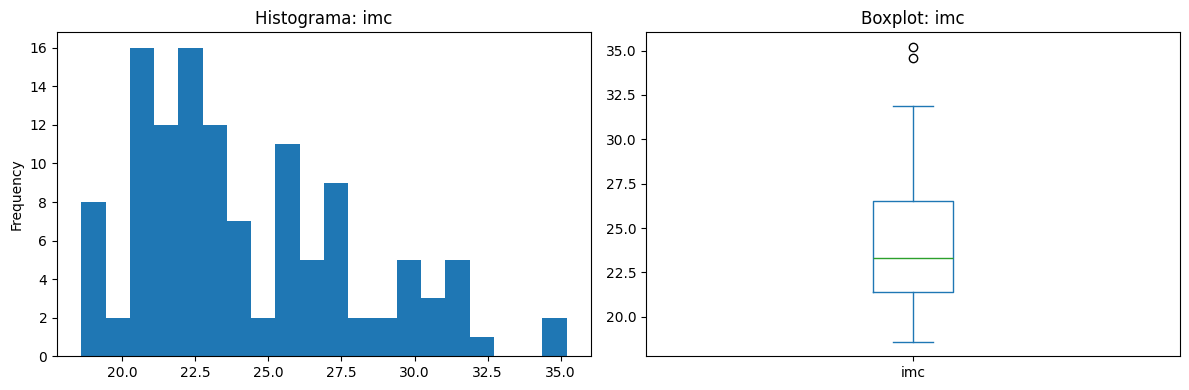


Riesgo global: {1: 103, 0: 17}


/tmp/ipykernel_34968/3575543100.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["cambio_afluencia"] = df_trabajo["afluencia_durante_ord"] - df_trabajo["afluencia_antes_ord"]
/tmp/ipykernel_34968/3575543100.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["riesgo_global"] = ((df_trabajo["tiene_comorbilidad"] == 1) | (df_trabajo["edad_clean"] > 60)).astype(int)


In [30]:
# 9.1 Variables derivadas

# IMC = peso (kg) / talla (m)^2
df_trabajo["imc"] = df_trabajo["peso_clean"] / (df_trabajo["talla_clean"] / 100) ** 2
df_trabajo["imc"] = df_trabajo["imc"].round(1)
print("IMC - estadísticas:")
print(df_trabajo["imc"].describe())
ver_numerica(df_trabajo, "imc")

# Cambio de afluencia (antes vs durante)
df_trabajo["cambio_afluencia"] = df_trabajo["afluencia_durante_ord"] - df_trabajo["afluencia_antes_ord"]

# Indicador de riesgo global: comorbilidad + edad > 60
df_trabajo["riesgo_global"] = ((df_trabajo["tiene_comorbilidad"] == 1) | (df_trabajo["edad_clean"] > 60)).astype(int)
print("\nRiesgo global:", df_trabajo["riesgo_global"].value_counts().to_dict())


In [31]:
# 9.2 Codificación de variables categóricas

# One-Hot Encoding para sexo (nominal, 2 categorías)
# Justificación: variable nominal sin orden lógico
df_trabajo["sexo_mujer"] = (df_trabajo["sexo_clean"] == "Mujer").astype(int)
print("One-Hot sexo (sexo_mujer):", df_trabajo["sexo_mujer"].value_counts().to_dict())

# Ordinal Encoding para domicilio (ya hay orden implícito por tamaño)
dom_ord_map = {
    "Casa con espacio al aire libre": 0,
    "Casa unifamiliar": 1,
    "Piso en bloque de menos 50 viviendas": 2,
    "Piso en bloque de más de 50 viviendas": 3,
}
df_trabajo["domicilio_antes_ord"] = df_trabajo["domicilio_antes_clean"].map(dom_ord_map)
# Justificación: hay un orden lógico de menor a mayor densidad de vivienda
print("Ordinal domicilio:", df_trabajo["domicilio_antes_ord"].value_counts().sort_index().to_dict())

# One-Hot para fumador_clean (nominal, varias categorías)
fum_dummies = pd.get_dummies(df_trabajo["fumador_clean"], prefix="fum", drop_first=True)
print("\nOne-Hot fumador:", list(fum_dummies.columns))
df_trabajo = pd.concat([df_trabajo, fum_dummies], axis=1)


One-Hot sexo (sexo_mujer): {1: 70, 0: 50}
Ordinal domicilio: {0: 2, 1: 19, 2: 80, 3: 19}

One-Hot fumador: ['fum_Fumador ocasional', 'fum_No', 'fum_No tabaco. Marihuana sin combustión p', 'fum_dejé de fumar en confinamiento']


/tmp/ipykernel_34968/1870085424.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["sexo_mujer"] = (df_trabajo["sexo_clean"] == "Mujer").astype(int)
/tmp/ipykernel_34968/1870085424.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["domicilio_antes_ord"] = df_trabajo["domicilio_antes_clean"].map(dom_ord_map)


In [32]:
# 9.3 Escalado/normalización de variables numéricas

from sklearn.preprocessing import MinMaxScaler, StandardScaler

vars_escalar = ["edad_clean", "peso_clean", "talla_clean", "imc", "numero_sintomas"]
vars_existentes = [v for v in vars_escalar if v in df_trabajo.columns and df_trabajo[v].notna().sum() > 0]

# Min-Max scaling
scaler_mm = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_mm.fit_transform(df_trabajo[vars_existentes].fillna(df_trabajo[vars_existentes].median())),
    columns=[f"{v}_minmax" for v in vars_existentes],
    index=df_trabajo.index)
print("Min-Max scaling aplicado a:", vars_existentes)
display(df_minmax.describe().round(3))

# Z-score (StandardScaler)
scaler_z = StandardScaler()
df_zscore = pd.DataFrame(
    scaler_z.fit_transform(df_trabajo[vars_existentes].fillna(df_trabajo[vars_existentes].median())),
    columns=[f"{v}_zscore" for v in vars_existentes],
    index=df_trabajo.index)
print("\nZ-score scaling aplicado a:", vars_existentes)
display(df_zscore.describe().round(3))

# Añadir al df de trabajo
df_trabajo = pd.concat([df_trabajo, df_minmax, df_zscore], axis=1)


Min-Max scaling aplicado a:

 ['edad_clean', 'peso_clean', 'talla_clean', 'imc', 'numero_sintomas']


,edad_clean_minmax,peso_clean_minmax,talla_clean_minmax,imc_minmax,numero_sintomas_minmax
count,120.000,120.000,120.000,120.000,120.000
mean,0.377,0.339,0.540,0.341,0.214
std,0.239,0.216,0.309,0.226,0.186
min,0.000,0.000,0.000,0.000,0.000
25%,0.187,0.176,0.333,0.169,0.067
50%,0.348,0.294,0.500,0.283,0.200
75%,0.554,0.475,0.833,0.479,0.333
max,1.000,1.000,1.000,1.000,1.000



Z-score scaling aplicado a: ['edad_clean', 'peso_clean', 'talla_clean', 'imc', 'numero_sintomas']


,edad_clean_zscore,peso_clean_zscore,talla_clean_zscore,imc_zscore,numero_sintomas_zscore
count,120.000,120.000,120.000,120.000,120.000
mean,-0.000,-0.000,-0.000,0.000,-0.000
std,1.004,1.004,1.004,1.004,1.004
min,-1.584,-1.579,-1.758,-1.515,-1.153
25%,-0.795,-0.757,-0.673,-0.765,-0.793
50%,-0.120,-0.209,-0.131,-0.256,-0.075
75%,0.744,0.635,0.954,0.615,0.644
max,2.622,3.077,1.496,2.932,4.236


In [33]:
# 9.4 Discretización

# Edad por rangos (justificación: grupos etarios clínicamente relevantes)
bins_edad = [0, 30, 45, 60, 100]
labels_edad = ["Joven (<=30)", "Adulto (31-45)", "Maduro (46-60)", "Mayor (>60)"]
df_trabajo["edad_grupo"] = pd.cut(df_trabajo["edad_clean"], bins=bins_edad, labels=labels_edad, include_lowest=True)
print("Discretización de edad:")
print(df_trabajo["edad_grupo"].value_counts().sort_index())

# IMC por categorías OMS
bins_imc = [0, 18.5, 25, 30, 100]
labels_imc = ["Bajo peso", "Normal", "Sobrepeso", "Obesidad"]
df_trabajo["imc_categoria"] = pd.cut(df_trabajo["imc"], bins=bins_imc, labels=labels_imc, include_lowest=True)
print("\nDiscretización de IMC (OMS):")
print(df_trabajo["imc_categoria"].value_counts().sort_index())

# Número de síntomas discretizado
bins_sint = [-1, 0, 3, 6, 20]
labels_sint = ["Sin síntomas", "Pocos (1-3)", "Moderados (4-6)", "Muchos (>6)"]
df_trabajo["sintomas_grupo"] = pd.cut(df_trabajo["numero_sintomas"], bins=bins_sint, labels=labels_sint)
print("\nDiscretización de síntomas:")
print(df_trabajo["sintomas_grupo"].value_counts().sort_index())


Discretización de edad:
edad_grupo
Joven (<=30)      16
Adulto (31-45)    46
Maduro (46-60)    38
Mayor (>60)       20
Name: count, dtype: int64

Discretización de IMC (OMS):
imc_categoria
Bajo peso     0
Normal       75
Sobrepeso    31
Obesidad     14
Name: count, dtype: int64

Discretización de síntomas:
sintomas_grupo
Sin síntomas       16
Pocos (1-3)        62
Moderados (4-6)    26
Muchos (>6)        16
Name: count, dtype: int64


/tmp/ipykernel_34968/30009560.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["edad_grupo"] = pd.cut(df_trabajo["edad_clean"], bins=bins_edad, labels=labels_edad, include_lowest=True)
/tmp/ipykernel_34968/30009560.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_trabajo["imc_categoria"] = pd.cut(df_trabajo["imc"], bins=bins_imc, labels=labels_imc, include_lowest=True)
/tmp/ipykernel_34968/30009560.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert

# 10. Reducción de datos

Debes construir una versión del dataset adecuada para un análisis posterior o para un modelo de aprendizaje automático.

## Objetivo

Crear `df_modelo` con aproximadamente **15 variables útiles**.

## Requisitos

1. No basta con elegir 15 columnas “porque sí”.
2. Debes justificar por qué eliminas:
   - columnas redundantes,
   - columnas con demasiados faltantes,
   - columnas excesivamente libres o difíciles de usar,
   - columnas que duplican información.
3. Puedes conservar:
   - columnas limpias originales,
   - variables derivadas,
   - columnas codificadas.
4. Si quieres, puedes apoyar la selección con:
   - sentido del dominio,
   - baja cardinalidad,
   - relación con el objetivo,
   - correlaciones,
   - variabilidad,
   - proporción de faltantes.

In [34]:
# Definición de df_limpio: todas las columnas limpias/derivadas
cols_limpio = [
    "cp_antes_clean", "barrio_antes_clean", "sexo_clean", "edad_clean", "peso_clean",
    "talla_clean", "domicilio_antes_clean", "afluencia_antes_clean", "afluencia_antes_ord",
    "convivientes_antes_clean", "profesion_antes_clean", "lugar_trabajo_antes_clean",
    "ocio_clean", "max_transporte", "viaje_extranjero_bin", "desplazamiento_nac_bin",
    "cp_durante_clean", "barrio_durante_clean", "domicilio_durante_clean",
    "afluencia_durante_clean", "afluencia_durante_ord", "convivientes_durante_clean",
    "tiene_mascota", "n_tipos_mascota", "n_formas_profesion", "lugar_trabajo_durante_clean",
    "mes_seguridad_ord", "media_seguridad",
    "fumador_clean", "fumador_bin", "alcohol_ord", "media_bebidas",
    "antidepresivos_bin", "tranquilizantes_bin", "trat_dolor_bin",
    "salud_general_ord", "n_enf_metabolica", "n_enf_autoinmune", "n_enf_alergia",
    "n_enf_respiratoria", "n_enf_cardiaca", "n_enf_otras", "total_enfermedades",
    "tiene_comorbilidad", "epoc_bin",
    "salud_trimestre_ord", "ingreso_hospital_bin", "visita_hospital_bin",
    "patologia_asist_bin", "patologia_sinasist_bin", "numero_sintomas",
    "sintoma_respiratorio", "sintoma_general", "sintoma_digestivo", "sintoma_neurologico",
    "n_vacunas", "covid_contacto_bin", "covid_sospecha_bin",
    "covid_pcr_realizada", "covid_pcr_positiva", "covid_anticuerpos",
    "imc", "cambio_afluencia", "riesgo_global", "sexo_mujer",
    "domicilio_antes_ord", "edad_grupo", "imc_categoria", "sintomas_grupo",
]
cols_limpio_exist = [c for c in cols_limpio if c in df_trabajo.columns]
df_limpio = df_trabajo[cols_limpio_exist].copy()
print(f"df_limpio: {df_limpio.shape[0]} filas × {df_limpio.shape[1]} columnas")
display(df_limpio.head())


df_limpio: 120 filas × 69 columnas


,cp_antes_clean,barrio_antes_clean,sexo_clean,edad_clean,peso_clean,talla_clean,domicilio_antes_clean,afluencia_antes_clean,afluencia_antes_ord,convivientes_antes_clean,profesion_antes_clean,lugar_trabajo_antes_clean,ocio_clean,max_transporte,viaje_extranjero_bin,desplazamiento_nac_bin,cp_durante_clean,barrio_durante_clean,domicilio_durante_clean,afluencia_durante_clean,afluencia_durante_ord,convivientes_durante_clean,tiene_mascota,n_tipos_mascota,n_formas_profesion,lugar_trabajo_durante_clean,mes_seguridad_ord,media_seguridad,fumador_clean,fumador_bin,alcohol_ord,media_bebidas,antidepresivos_bin,tranquilizantes_bin,trat_dolor_bin,salud_general_ord,n_enf_metabolica,n_enf_autoinmune,n_enf_alergia,n_enf_respiratoria,n_enf_cardiaca,n_enf_otras,total_enfermedades,tiene_comorbilidad,epoc_bin,salud_trimestre_ord,ingreso_hospital_bin,visita_hospital_bin,patologia_asist_bin,patologia_sinasist_bin,numero_sintomas,sintoma_respiratorio,sintoma_general,sintoma_digestivo,sintoma_neurologico,n_vacunas,covid_contacto_bin,covid_sospecha_bin,covid_pcr_realizada,covid_pcr_positiva,covid_anticuerpos,imc,cambio_afluencia,riesgo_global,sexo_mujer,domicilio_antes_ord,edad_grupo,imc_categoria,sintomas_grupo
0,14005,14005,Hombre,42.0,72.0,167.0,Piso en bloque de menos 50 viviendas,Alto,2,0,Ámbito educativo,Otro,En lugares abiertos y cerrados por igual,4.0,0,0.0,14005,Ciudad Jardín,Piso en bloque de más de 50 viviendas,Alto,2.0,0.0,1.0,1,1,En el hogar (teletrabajo/en paro/ tareas domésticas/confinado),3.0,2.0,No,1,NaN,NaN,0.0,0.0,0.0,4.0,1,0,0,1,0,1,3,1,0.0,4.0,0.0,0,NaN,0.0,3.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0,25.8,0.0,1,0,2,Adulto (31-45),Sobrepeso,Pocos (1-3)
1,28002,Prosperidad,Mujer,56.0,65.0,167.0,Piso en bloque de menos 50 viviendas,Medio,1,0,Medios de comunicación,"Trabajo en espacios con afluencia de < 10 personas (oficinas, laboratorios, pequeña empresa, talleres)","Principalmente en lugares cerrados (restaurantes, cafeterías, bares, locales de ocio, cines, gimnasios...)",4.0,0,0.0,28002,Prosperidad,Piso en bloque de menos 50 viviendas,Medio,1.0,0.0,NaN,0,1,"Trabajo en espacios con afluencia de < 10 personas (oficinas, laboratorios, pequeña empresa, talleres)",3.0,2.0,No,1,NaN,NaN,0.0,0.0,0.0,3.0,2,0,1,2,0,0,5,1,0.0,2.0,0.0,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0,0,0,23.3,0.0,1,1,2,Maduro (46-60),Normal,Sin síntomas
2,29006,Cruz Humilladero ( Málaga),Mujer,33.0,88.0,167.0,Piso en bloque de menos 50 viviendas,Alto,2,0,Ámbito del ocio y la restauración,"Trabajo en espacios con afluencia de > de 10 personas (gimnasios, restaurantes, bares, cafeterias, grandes superficies)",En lugares abiertos y cerrados por igual,4.0,0,1.0,29006,Cruz Humilladero ( Málaga),Piso en bloque de menos 50 viviendas,Medio,1.0,0.0,1.0,1,1,En el hogar (teletrabajo/en paro/ tareas domésticas/confinado),2.0,2.0,Fumador ocasional,1,NaN,NaN,0.0,0.0,0.0,2.0,1,0,4,3,0,0,8,1,0.0,2.0,0.0,1,1.0,1.0,9.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0,0,0,31.6,-1.0,1,1,2,Adulto (31-45),Obesidad,Muchos (>6)
3,38204,Casco Histórico,Mujer,65.0,58.0,167.0,Piso en bloque de menos 50 viviendas,Alto,2,0,Ámbito educativo,Otro,En lugares abiertos y cerrados por igual,4.0,0,0.0,38204,Casco Bistorico,Piso en bloque de menos 50 viviendas,Alto,2.0,0.0,0.0,0,0,Otro,3.0,1.0,Fumador habitual,1,NaN,NaN,0.0,0.0,0.0,2.0,1,0,1,3,1,0,6,1,1.0,3.0,0.0,0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,20.8,0.0,1,1,2,Mayor (>60),Normal,Pocos (1-3)
4,38201,La Laguna Centro,Mujer,63.0,59.0,167.0,Piso en bloque de menos 50 viviendas,Alto,2,0,Ámbito administrativo,"Trabajo en espacios con afluencia de < 10 personas (oficinas, laboratorios, pequeña empresa, talleres)",En lugares abiertos y cerrados por igual,4.0,0,0.0,38201,La Laguna Centro,Piso en bloque de menos 50 viviendas,Bajo,0.0,0.0,1.0,1,1,En el hogar (teletrabajo/en paro/ tareas domésticas/confinado),3.0,2.0,Fumador habitual,1,0.0,NaN,0.0,0.0,0.0,3.0,0,0,1,1,0,1,3,1,0.0,3.0,0.0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,0,0,21.2,-2.0,1,1,2,Mayor (>60),Normal,Pocos (

In [35]:
# df_modelo con ~15 variables útiles
# Selección justificada de variables para análisis/modelado

cols_modelo = [
    "sexo_mujer",          # Demográfico básico
    "edad_clean",          # Demográfico básico
    "imc",                 # Indicador de salud derivado
    "afluencia_antes_ord", # Contexto social
    "cambio_afluencia",    # Cambio de contexto pre/post
    "media_seguridad",     # Cumplimiento medidas seguridad
    "fumador_bin",         # Factor de riesgo
    "alcohol_ord",         # Factor de riesgo
    "salud_general_ord",   # Autoevaluación salud
    "total_enfermedades",  # Comorbilidad
    "salud_trimestre_ord", # Salud durante confinamiento
    "numero_sintomas",     # Sintomatología
    "n_vacunas",           # Historial vacunal
    "covid_sospecha_bin",  # Variable de interés clínica
    "riesgo_global",       # Indicador de riesgo compuesto
]
df_modelo = df_trabajo[cols_modelo].copy()
print(f"df_modelo: {df_modelo.shape[0]} filas × {df_modelo.shape[1]} columnas")
display(df_modelo.describe().round(2))


df_modelo: 120 filas × 15 columnas


,sexo_mujer,edad_clean,imc,afluencia_antes_ord,cambio_afluencia,media_seguridad,fumador_bin,alcohol_ord,salud_general_ord,total_enfermedades,salud_trimestre_ord,numero_sintomas,n_vacunas,covid_sospecha_bin,riesgo_global
count,120.00,120.00,120.00,120.00,117.00,108.00,120.0,28.0,120.00,120.00,119.00,120.00,120.00,115.00,120.00
mean,0.58,46.09,24.25,1.21,-0.48,1.42,1.0,0.0,3.12,2.84,3.01,3.21,1.91,0.12,0.86
std,0.50,13.37,3.75,0.66,0.82,0.79,0.0,0.0,0.57,2.44,0.60,2.80,1.71,0.33,0.35
min,0.00,25.00,18.60,0.00,-2.00,0.00,1.0,0.0,2.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,0.00,35.50,21.40,1.00,-1.00,1.00,1.0,0.0,3.00,1.00,3.00,1.00,1.00,0.00,1.00
50%,1.00,44.50,23.30,1.00,0.00,2.00,1.0,0.0,3.00,2.00,3.00,3.00,2.00,0.00,1.00
75%,1.00,56.00,26.55,2.00,0.00,2.00,1.0,0.0,3.00,4.00,3.00,5.00,3.00,0.00,1.00
max,1.00,81.00,35.20,2.00,2.00,2.00,1.0,0.0,4.00,11.00,4.00,15.00,7.00,1.00,1.00


In [36]:
# Justificación de la selección de variables para df_modelo
justificacion = pd.DataFrame([
    ("sexo_mujer", "Demográfico", "One-hot", "Variable demográfica básica sin faltantes"),
    ("edad_clean", "Demográfico", "Numérica imputada", "Asociada con riesgo COVID"),
    ("imc", "Derivada", "Calculado peso/talla", "Indicador de salud metabólica"),
    ("afluencia_antes_ord", "Contexto", "Ordinal 0-2", "Exposición social pre-confinamiento"),
    ("cambio_afluencia", "Derivada", "Diferencia ordinal", "Cambio de exposición por confinamiento"),
    ("media_seguridad", "Comportamiento", "Promedio ordinal", "Nivel de cumplimiento de medidas"),
    ("fumador_bin", "Hábito", "Binaria", "Factor de riesgo respiratorio conocido"),
    ("alcohol_ord", "Hábito", "Ordinal 0-2", "Factor de riesgo de salud"),
    ("salud_general_ord", "Salud", "Ordinal 0-4", "Autoevaluación del estado de salud"),
    ("total_enfermedades", "Salud", "Conteo", "Carga total de comorbilidades"),
    ("salud_trimestre_ord", "Salud", "Ordinal 0-4", "Estado de salud durante confinamiento"),
    ("numero_sintomas", "Salud", "Conteo", "Carga sintomatológica reciente"),
    ("n_vacunas", "Inmunización", "Conteo", "Cobertura vacunal previa"),
    ("covid_sospecha_bin", "COVID", "Binaria", "Variable objetivo potencial"),
    ("riesgo_global", "Derivada", "Binaria", "Combina edad y comorbilidad"),
], columns=["variable", "categoría", "tipo_tratamiento", "justificación"])
display(justificacion)

# Análisis de correlaciones para apoyar la selección
print("\nMatriz de correlación (variables numéricas del modelo):")
corr = df_modelo.corr().round(2)
display(corr)

# Comprobar qu no hay variables muy correlacionadas (|r| > 0.85)
import itertools
for c1, c2 in itertools.combinations(df_modelo.columns, 2):
    r = corr.loc[c1, c2]
    if abs(r) > 0.85:
        print(f"⚠️ Alta correlación: {c1} vs {c2} = {r}")


,variable,categoría,tipo_tratamiento,justificación
0,sexo_mujer,Demográfico,One-hot,Variable demográfica básica sin faltantes
1,edad_clean,Demográfico,Numérica imputada,Asociada con riesgo COVID
2,imc,Derivada,Calculado peso/talla,Indicador de salud metabólica
3,afluencia_antes_ord,Contexto,Ordinal 0-2,Exposición social pre-confinamiento
4,cambio_afluencia,Derivada,Diferencia ordinal,Cambio de exposición por confinamiento
5,media_seguridad,Comportamiento,Promedio ordinal,Nivel de cumplimiento de medidas
6,fumador_bin,Hábito,Binaria,Factor de riesgo respiratorio conocido
7,alcohol_ord,Hábito,Ordinal 0-2,Factor de riesgo de salud
8,salud_general_ord,Salud,Ordinal 0-4,Autoevaluación del estado de salud
9,total_enfermedades,Salud,Conteo,Carga total de comorbilidades



Matriz de correlación (variables numéricas del modelo):


,sexo_mujer,edad_clean,imc,afluencia_antes_ord,cambio_afluencia,media_seguridad,fumador_bin,alcohol_ord,salud_general_ord,total_enfermedades,salud_trimestre_ord,numero_sintomas,n_vacunas,covid_sospecha_bin,riesgo_global
sexo_mujer,1.00,-0.34,-0.39,0.17,-0.07,0.12,NaN,NaN,-0.06,0.04,-0.02,0.21,-0.12,0.15,0.04
edad_clean,-0.34,1.00,0.31,-0.15,-0.01,-0.05,NaN,NaN,-0.13,0.13,-0.18,-0.24,0.04,-0.05,0.23
imc,-0.39,0.31,1.00,-0.07,0.03,-0.19,NaN,NaN,-0.12,0.19,-0.04,-0.05,0.12,-0.13,0.04
afluencia_antes_ord,0.17,-0.15,-0.07,1.00,-0.54,0.09,NaN,NaN,-0.07,0.06,-0.05,0.05,0.11,0.12,0.09
cambio_afluencia,-0.07,-0.01,0.03,-0.54,1.00,-0.20,NaN,NaN,0.09,-0.11,0.13,-0.07,-0.19,-0.07,-0.00
media_seguridad,0.12,-0.05,-0.19,0.09,-0.20,1.00,NaN,NaN,-0.12,0.13,-0.20,0.21,0.05,0.01,0.11
fumador_bin,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alcohol_ord,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salud_general_ord,-0.06,-0.13,-0.12,-0.07,0.09,-0.12,NaN,NaN,1.00,-0.36,0.69,-0.18,0.03,-0.03,-0.30
total_enfermedades,0.04,0.13,0.19,0.06,-0.11,0.13,NaN,NaN,-0.36,1.00,-0.41,0.36,0.11,0.03,0.47


# 11. Guardado de resultados

Cuando termines, guarda:

- la tabla de auditoría;
- el dataset limpio;
- el dataset reducido.

In [37]:
# Guardado de resultados
auditoria.to_excel(f"Auditoria_EncuestaCOVID_{codigo:02d}.xlsx", index=False)
print(f"✓ Guardado: Auditoria_EncuestaCOVID_{codigo:02d}.xlsx")

df_limpio.to_excel(f"DatosEncuestaCOVID_limpio_{codigo:02d}.xlsx", index=False)
print(f"✓ Guardado: DatosEncuestaCOVID_limpio_{codigo:02d}.xlsx ({df_limpio.shape})")

df_modelo.to_excel(f"DatosEncuestaCOVID_modelo_{codigo:02d}.xlsx", index=False)
print(f"✓ Guardado: DatosEncuestaCOVID_modelo_{codigo:02d}.xlsx ({df_modelo.shape})")

print("\n🎉 Práctica completada. Entregables generados.")


✓ Guardado: Auditoria_EncuestaCOVID_40.xlsx


✓ Guardado: DatosEncuestaCOVID_limpio_40.xlsx ((120, 69))


✓ Guardado: DatosEncuestaCOVID_modelo_40.xlsx ((120, 15))

🎉 Práctica completada. Entregables generados.


# 12. Checklist final antes de entregar

Comprueba que tu notebook:

- carga solo tus 120 filas;
- mantiene una copia cruda (`df_raw`);
- contiene una auditoría **columna a columna**;
- detecta faltantes, inconsistencias y outliers;
- limpia y transforma con código;
- crea variables derivadas;
- aplica alguna codificación;
- aplica alguna normalización o discretización;
- construye `df_limpio`;
- construye `df_modelo`;
- guarda los resultados.

## Nota importante

El número real de columnas del XLSX debe comprobarse con `df.shape` y `df.info()`.  
No asumas el número de columnas sin verificarlo en tu fichero.